# 1. Setup

In [1]:
# Imports
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import expit 
from scipy.optimize import minimize 
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon, friedmanchisquare

In [2]:
# Reproducibility
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
# Project paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "PD_data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

# Create output directories if they do not exist
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [4]:
# Dataset settings
RUN_A_KEY = "data_train"
RUN_B_KEY = "data_test"

N_EXPECTED_PARTICIPANTS = 49

# 2. Data Loading and Preparation

## 2.1 Data Preparation

The raw trial data are converted into the variables used throughout the analysis. Invalid trials are removed, probability values are rescaled to the interval [0, 1], and choices are recoded as 1 = certain and 0 = uncertain.

In [5]:
# Load participant files
mat_files = sorted(DATA_DIR.glob("*.mat"))

assert DATA_DIR.exists(), f"Data direcotry not found: {DATA_DIR}"
assert len(mat_files) == N_EXPECTED_PARTICIPANTS, (
    f"Expected {N_EXPECTED_PARTICIPANTS} participant files, "
    f"but found {len(mat_files)}."
)
print("Number of participant files:", len(mat_files))
print("First file:", mat_files[0].name)

Number of participant files: 49
First file: 2rrjzhgj9.mat


In [6]:
# Check one file
example = sio.loadmat(mat_files[0])

print(example.keys()) 
print("Run A shape:", example[RUN_A_KEY].shape) 
print("Run B shape:", example[RUN_B_KEY].shape) 
print("Labels:", example["data_labels"])

dict_keys(['__header__', '__version__', '__globals__', 'data_labels', 'data_test', 'data_train'])
Run A shape: (200, 8)
Run B shape: (200, 8)
Labels: [[array(['certOutcome'], dtype='<U11')
  array(['uncOutcome'], dtype='<U10')
  array(['outcome prob.'], dtype='<U13')
  array(['action (1=certain, 2=uncertain, 0=missing)'], dtype='<U42')
  array(['p_cert'], dtype='<U6')
  array(['condition (1=reward,2=loss)'], dtype='<U27')
  array(['RT'], dtype='<U2') array(['odds'], dtype='<U4')]]


In [7]:
# Column indices
COL_R_CERT = 0      # 0 = certain outcome
COL_R_UNCERT = 1    # 1 = uncertain outcome
COL_P = 2           # 2 = outcome probability
COL_CHOICE = 3      # 3 = action, where 1=certain, 2=uncertain, 0=missing
COL_P_CERT = 4
COL_CONDITION = 5   # 5 = condition, where 1=reward, 2=loss
COL_RT = 6          # 6 = reaction time
COL_ODDS = 7

In [8]:
# Prepare trial data
def prepare_data(data):
    data = np.asarray(data, dtype=float)

    # Remove missing choices and invalid RTs
    valid = (
        np.isin(data[:, COL_CHOICE], [1, 2])
        & np.isfinite(data[:, COL_RT]) 
        & (data[:, COL_RT] > 0) 
    )
    data = data[valid]

    r_cert = data[:, COL_R_CERT]
    r_uncert = data[:, COL_R_UNCERT]
    p = data[:, COL_P]
    choice = data[:, COL_CHOICE]
    condition = data[:, COL_CONDITION]
    rt = data[:, COL_RT]
    
    # Convert probabilities from percentages to proportions
    if np.nanmax(p) > 1: 
        p = p / 100.0
        
    # Recode choice:
    # original 1 = certain -> y = 1 
    # original 2 = uncertain -> y = 0 
    y = (choice == 1).astype(int)

    return r_cert, r_uncert, p, y, rt, condition

## 2.2 Sanity Checks

Before preprocessing, the raw data are inspected for missing choices, missing or non-positive RTs, and the distribution of reward and loss trials.

In [9]:
summary = []

# Loop over all participant .mat files
for file in mat_files:
    # Each file contains both experimental runs for one participant
    participant = sio.loadmat(file)

    # Check Run A (used for inference) and Run B (used for evaluation) separately
    for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
        # Load the raw trial matrix for the current participant and run
        data = np.asarray(participant[run_key], dtype=float)

        # Extract variables needed for the data-quality checks
        choice = data[:, COL_CHOICE]
        condition = data[:, COL_CONDITION]
        rt = data[:, COL_RT]

        # Identify missing choices and missing RTs before prepare_data() removes them
        choice_missing = (choice == 0) | ~np.isfinite(choice)
        rt_missing = ~np.isfinite(rt)

        # Store participant- and run-level counts for later aggregation.
        summary.append({
            "participant": file.stem,
            "run": run_name,
            "n_trials": len(data),

            # Count missing responses and missing RT observations
            "missing_choice": choice_missing.sum(),
            "missing_rt": rt_missing.sum(),

            # Check whether missingness occurs in choice, RT, or both on the same trial.
            "choice_missing_rt_valid": np.sum(choice_missing & ~rt_missing),
            "choice_valid_rt_missing": np.sum(~choice_missing & rt_missing),
            "choice_missing_rt_missing": np.sum(choice_missing & rt_missing),

            # RTs must be strictly positive for the shifted log-normal model.
            "nonpositive_rt": np.sum(np.isfinite(rt) & (rt <= 0)),

            # Verify the number of reward and loss trials in each run
            "reward_trials": np.sum(condition == 1),
            "loss_trials": np.sum(condition == 2)
        })

# Convert all participant-level sanity checks into one DataFrame
sanity_df = pd.DataFrame(summary)

# Aggregate the checks across participants to summarize each experimental run
display(sanity_df.groupby("run").agg({
    "n_trials": "sum",
    "missing_choice": "sum",
    "missing_rt": "sum",
    "choice_missing_rt_valid": "sum",
    "choice_valid_rt_missing": "sum",
    "choice_missing_rt_missing": "sum",
    "nonpositive_rt": "sum",
    "reward_trials": "sum",
    "loss_trials": "sum",    
}))

,n_trials,missing_choice,missing_rt,choice_missing_rt_valid,choice_valid_rt_missing,choice_missing_rt_missing,nonpositive_rt,reward_trials,loss_trials
run,,,,,,,,,
Run A,9800,51,51,0,0,51,0,4900,4900
Run B,9800,17,17,0,0,17,0,4900,4900


The sanity checks show that choice and RT observations are either both present or both missing within a trial. There are no trials with a valid choice but missing RT, or with a missing choice but valid RT.

Therefore, for the present dataset, filtering trials jointly by valid choice and RT does not remove any additional choice observations. No non-positive RTs were observed.

## 2.3 Basic Descriptive Statistics

Basic behavioral summaries are computed separately for each participant, run, and outcome condition. These summaries describe choice behavior and the central tendency and variability of RTs before model fitting.

In [10]:
def compute_basic_descriptives(mat_files):
    """Compute choice and RT descriptives by run and condition."""
    rows = []

    # Loop over all participants and analyze Run A and Run B separately
    for file in mat_files:
        participant = sio.loadmat(file)

        for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
            data = participant[run_key]

            # Apply the same preprocessing that will later be used for model fitting
            _, _, _, y, rt, condition = prepare_data(data)

            # Compute behavioral summaries separately for reward and loss trials
            for condition_value, condition_label in [(1, "reward"), (2, "loss")]:
                mask = condition == condition_value

                # Store choice behavior and the RT distribution for this participant
                rows.append({
                    "participant": file.stem,
                    "run": run_name,
                    "condition": condition_label,
                    "n_trials": mask.sum(),
                    "certain_choice_proportion": y[mask].mean(),
                    "mean_rt": rt[mask].mean(),
                    "median_rt": np.median(rt[mask]),
                    "std_rt": rt[mask].std(ddof=1),
                    "rt_q05": np.quantile(rt[mask], 0.05),
                    "rt_q95": np.quantile(rt[mask], 0.95)
                })
    return pd.DataFrame(rows)

In [11]:
# Compute participant-level descriptives and inspect the resulting table
basic_descriptives = compute_basic_descriptives(mat_files)
basic_descriptives.head()

,participant,run,condition,n_trials,certain_choice_proportion,mean_rt,median_rt,std_rt,rt_q05,rt_q95
0,2rrjzhgj9,Run A,reward,99,0.414141,2501.584848,2267.70,1299.541548,1413.180,3971.570
1,2rrjzhgj9,Run A,loss,100,0.530000,2419.590000,2322.10,717.064108,1331.150,3735.680
2,2rrjzhgj9,Run B,reward,100,0.590000,2032.914000,1673.65,1459.732253,930.990,4346.240
3,2rrjzhgj9,Run B,loss,100,0.560000,2331.486000,2094.70,1195.778142,1012.445,4779.440
4,3lmzwis6r,Run A,reward,100,0.450000,3003.521000,2828.55,1283.768528,1488.580,5320.155


In [12]:
# Aggregate participant-level descriptives by run and outcome condition
basic_descriptives_summary = (
    basic_descriptives.groupby(["run", "condition"])
    .agg(
        # Sample size and number of usable trials
        participants=("participant", "nunique"), 
        mean_valid_trials=("n_trials", "mean"),

        # Choice behavior across participants
        mean_certain_choice_proportion=("certain_choice_proportion", "mean"),
        sd_certain_choice_proportion=("certain_choice_proportion", "std"),

        # RT central tendency and variability across participants
        mean_participant_mean_rt=("mean_rt", "mean"),
        median_participant_median_rt=("median_rt", "median"),
        mean_participant_rt_sd=("std_rt", "mean"),

        # Typical lower and upper RT quantiles across participants
        median_participant_rt_q05=("rt_q05", "median"),
        median_participant_rt_q95=("rt_q95", "median"))
    .reset_index()
)
basic_descriptives_summary

,run,condition,participants,mean_valid_trials,mean_certain_choice_proportion,sd_certain_choice_proportion,mean_participant_mean_rt,median_participant_median_rt,mean_participant_rt_sd,median_participant_rt_q05,median_participant_rt_q95
0,Run A,loss,49,99.183673,0.614329,0.137350,2737.264323,2450.5,1190.094185,1271.54,5029.290
1,Run A,reward,49,99.775510,0.597717,0.176422,2299.871598,2038.9,1052.056967,1188.46,4108.885
2,Run B,loss,49,99.775510,0.519980,0.169679,2060.173486,1833.9,955.503185,1031.05,3877.700
3,Run B,reward,49,99.877551,0.474191,0.205190,1854.191345,1708.5,886.754204,1070.92,3525.750


## 2.4 RT Distributions

RT distributions are visualized separately by run and outcome condition to inspect their overall shape and possible differences between conditions.

In [13]:
def collect_rt_by_run_condition(mat_files):
    """Collect valid RTs by run and condition."""
    rows = []

    # Loop over participants and collect RTs from both experimental runs
    for file in mat_files:
        participant = sio.loadmat(file)

        for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
            data = participant[run_key]

            # Apply the common preprocessing and retain RT and condition labels
            _, _, _, _, rt, condition = prepare_data(data)

            # Store each valid trial so RT distributions can be plotted by condition
            for rt_value, condition_value in zip(rt, condition):
                rows.append({
                    "run": run_name,
                    "condition": ("reward" if condition_value == 1 else "loss"),
                    "rt": rt_value
                })

    # Each row represents one valid trial with its run, condition, and RT
    return pd.DataFrame(rows)

In [14]:
# Collect trial-level RTs used for the distribution plots below
rt_descriptive_data = collect_rt_by_run_condition(mat_files)

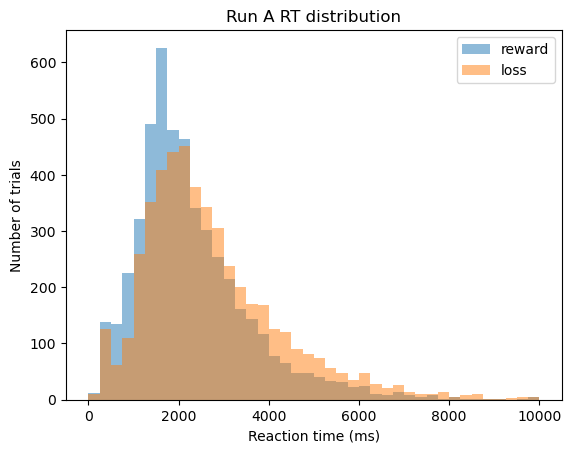

In [15]:
# Use common bin edges so reward and loss distributions are directly comparable
bins = np.linspace(0, 10000, 41)

# Plot reward and loss RT distributions for Run A
for condition in ["reward", "loss"]:
    values = rt_descriptive_data.loc[
        (rt_descriptive_data["run"] == "Run A") 
        & (rt_descriptive_data["condition"] == condition),
        "rt"
    ]

    # Overlay both conditions using the same histogram bins
    plt.hist(values, bins=bins, alpha=0.5, label=condition)
    
plt.xlabel("Reaction time (ms)")
plt.ylabel("Number of trials")
plt.title("Run A RT distribution")
plt.legend()
plt.show()

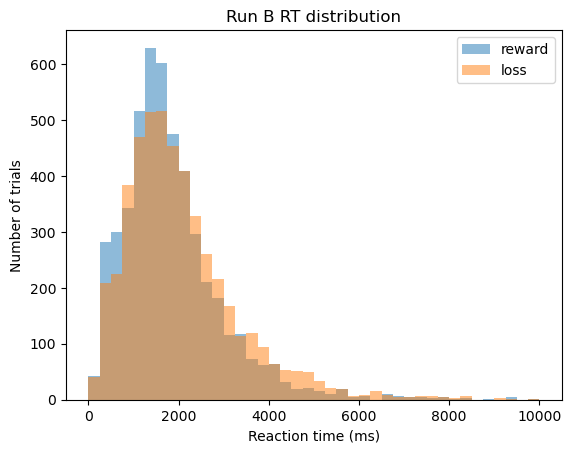

In [16]:
# Plot reward and loss RT distributions for Run B using the same binning
for condition in ["reward", "loss"]:
    values = rt_descriptive_data.loc[
        (rt_descriptive_data["run"] == "Run B") 
        & (rt_descriptive_data["condition"] == condition),
        "rt"
    ]

    # Overlay both conditions to compare their RT distributions
    plt.hist(values, bins=bins, alpha=0.5, label=condition)
    
plt.xlabel("Reaction time (ms)")
plt.ylabel("Number of trials")
plt.title("Run B RT distribution")
plt.legend()
plt.show()

Both runs show positively skewed RT distributions. RTs are generally slower in Run A than in Run B, and loss trials tend to show longer RTs than reward trials.

# 3. Shared Model Components

The following functions define the valuation model, choice rule, and observation likelihoods shared across all model specifications.

In [17]:
# Hyperbolic subjective valuation
def compute_subjective_values(r_cert, r_uncert, p, h): 
    """Compute subjective values under hyperbolic probability discounting."""

    # Keep probabilities away from 0 and 1 for numerically stable odds calculations
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps) 

    # Convert outcome probability into odds against receiving the uncertain outcome    
    theta = (1 - p) / p

    # The certain outcome is undiscounted, while the uncertain outcome is discounted by h
    v_cert = r_cert
    v_uncert = r_uncert / (1 + h * theta)
    
    return v_cert, v_uncert

In [18]:
# Subjective value difference
def compute_value_difference(v_cert, v_uncert):
    """Compute subjective value difference."""
    return v_cert - v_uncert

In [19]:
# Logistic choice rule
def compute_choice_probability(delta_v, beta):
    """Compute probability of choosing the certain option."""
    return expit(beta * delta_v)

In [20]:
# Bernoulli choice log-likelihood
def choice_log_likelihood(y, pi):
    """Bernoulli log-likelihood for binary choices."""

    # Avoid log(0) when predicted choice probabilities are numerically 0 or 1
    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)
    
    return np.sum(y * np.log(pi) + (1 - y) * np.log(1 - pi))

In [21]:
# Shifted log-normal RT likelihood
def shifted_lognormal_log_likelihood(rt, mu, sigma, tau):
    """Log-likelihood of RT under a shifted log-normal distribution."""

    # Enforce valid scale and non-decision-time parameters
    if sigma <= 0 or tau < 0:
        return -np.inf

    # Remove the non-decision-time shift before applying the log-normal model
    rt_shifted = rt - tau

    # The shifted RT must remain strictly posoitive for every trial
    if np.any(rt_shifted <= 0):
        return -np.inf

    # Under the model, log(RT - tau) is normally distributed around mu
    log_rt = np.log(rt_shifted)

    return np.sum(-np.log(rt_shifted) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - ((log_rt - mu) ** 2) / (2 * sigma ** 2))

# 4. Model Specifications

The choice-only baseline and all three full models use the same subjective valuation and logistic choice rule. The full models differ only in how the shared value difference is mapped onto the RT location parameter $\mu$.

## 4.1. Choice-Only Model

The choice-only baseline uses the shared valuation and choice components without an RT likelihood term.

In [22]:
def nll_choice_only(params, data): 
    beta, h = params

    # Safety check
    if beta < 0 or h < 0:
        return np.inf

    # Prepare data
    r_cert, r_uncert, p, y, _, _ = prepare_data(data)

    # Shared valuation
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h) 

    # Delta V
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Choice probability
    pi = compute_choice_probability(delta_v, beta)

    # Bernoulli choice likelihood
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Optimizers minimize, so return the negative log-likelihood
    return -log_likelihood_choice

## 4.2. RT Model 1: Absolute Conflict

The absolute model maps the magnitude of the subjective value difference linearly onto the RT location parameter.

In [23]:
def nll_absolute_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Absolute conflict
    conflict = np.abs(delta_v)
    mu = a - b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

## 4.3. RT Model 2: Squared Conflict

The squared model uses the squared subjective value difference, making the RT location increasingly sensitive to larger value difference.

In [24]:
def nll_squared_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Squared conflict
    conflict = delta_v ** 2
    mu = a - b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

## 4.4. RT model 3: Exponential Value-Difference Mapping

The exponential model assigns the strongest RT effect near subjective indifference and lets this effect decay rapidly as the value difference grows.

In [25]:
def nll_exponential_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Exponential conflict
    conflict = np.exp(-(delta_v ** 2))
    mu = a + b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

# 5. Model Fitting

All models are estimated separately for each participant using maximum likelihood and L-BFGS-B optimization. Multiple starting points are used to reduce sensitivity to local optima.

## 5.1. Shared Fitting Utilities

In [26]:
# Optimization helpers
OPT_EPS = 1e-6
H_MAX = 100.0

# Parameter names
CHOICE_PARAMETERS = ["beta", "h"]
FULL_PARAMETERS = ["beta", "h", "a", "b", "sigma", "tau"]

def is_valid_optimization_result(result):
    """Check whether an optimization result is usable."""
    return (
        result.success 
        and np.isfinite(result.fun) 
        and np.all(np.isfinite(result.x))
    )

def get_full_model_bounds(rt):
    """Return parameter bounds for the full choice + RT models."""
    # tau must remain below the smallest observed RT so that RT - tau stays positive
    min_rt = np.min(rt)

    bounds = [
        (0, None),              # beta
        (0, H_MAX),             # h
        (None, None),           # a
        (0, None),              # b
        (OPT_EPS, None),        # sigma
        (0, min_rt - OPT_EPS)   # tau
    ]

    return bounds

In [27]:
def run_multistart_optimization(objective_function, data, initial_conditions, bounds, optimizer_options=None):
    """Run multi-start L-BFGS-B optimization and return the best valid fit."""
    # Use default optimizer settings unless model-specific settings are supplied
    if optimizer_options is None:
        optimizer_options = {"maxiter": 500, "ftol": 1e-7}

    best_result = None
    all_results = []

    # Fit the same model repeatedly from different parameter starting points
    for x0 in initial_conditions:
        result = minimize(objective_function, 
                          x0=x0, 
                          args=(data,), 
                          method="L-BFGS-B", 
                          bounds=bounds, 
                          options=optimizer_options
                          )
        
        all_results.append(result)

        # Retain the valid solution with the lowest negative log-likelihood
        if (is_valid_optimization_result(result)
            and (best_result is None or result.fun < best_result.fun)):
            best_result = result
    return best_result, all_results

## 5.2. Choice-Only Model Fitting

In [28]:
def initial_conditions_choice_only():
    """Generate starting points for the choice-only model."""

    # Cover a broad range of possible beta and h values
    beta_values = [0.001, 0.1, 1, 3, 10, 30, 100] 
    h_values = [0.001, 0.1, 1, 3, 10, 30, 100]

    initial_conditions = []

    # Use every beta-h combination as an independent optimization start
    for beta in beta_values: 
        for h in h_values:
            initial_conditions.append([beta, h]) 

    return initial_conditions

In [29]:
def fit_choice_only(data):
    """Fit the choice-only model using multi-start L-BFGS-B optimization."""
    bounds = [(0, None), (0, H_MAX)] # beta, h
    initial_conditions = initial_conditions_choice_only()
    return run_multistart_optimization(nll_choice_only, data, initial_conditions, bounds)

## 5.3. Shared RT Initialization

In [30]:
def data_informed_rt_start(data, beta_start, h_start, tau_start, model_name):
    """Create a data-informed starting point for one RT model."""
    # Extract the trial variables needed to initialize the RT parameters
    r_cert, r_uncert, p, _, rt, _ = prepare_data(data)

    # Remove the proposed RT shift before moving to log-RT space
    rt_shifted = rt - tau_start

    # The shifted RT must remain strictly positive
    if np.any(rt_shifted <= 0):
        raise ValueError("tau_start must be smaller than all observed RTs.")
    
    log_rt = np.log(rt_shifted)

    # Subjective values at the proposed h
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h_start)
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Model-specific value-to-RT predictor
    if model_name == "absolute":
        predictor = np.abs(delta_v)
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(-slope, OPT_EPS)
        a0 =  np.mean(log_rt + b0 * predictor)
        mu0 = a0 - b0 * predictor

    elif model_name == "squared":
        predictor = (delta_v ** 2)
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(-slope, OPT_EPS)
        a0 =  np.mean(log_rt + b0 * predictor)
        mu0 = a0 - b0 * predictor

    elif model_name == "exponential":
        predictor = np.exp(-(delta_v ** 2))
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(slope, OPT_EPS)
        a0 =  np.mean(log_rt - b0 * predictor)
        mu0 = a0 + b0 * predictor

    else:
        raise ValueError(f"Unknown RT model: {model_name}")

    # Initialize sigma from the residual variability around the proposed RT mean
    sigma0 = max(np.std(log_rt - mu0, ddof=1), OPT_EPS)

    return np.array([beta_start, h_start, a0, b0, sigma0, tau_start])

In [31]:
def initial_conditions_rt_model(data, choice_result, model_name):
    """Generate local and global starting points for one RT model."""

    # Use fitted choice-only parameters as the center of the local search
    beta0, h0 = choice_result.x

    _, _, _, _, rt, _ = prepare_data(data)
    min_rt = np.min(rt)

    # Data-informed starting solution at tau = 0
    base = data_informed_rt_start(
        data=data, beta_start=beta0, h_start=h0, tau_start=0.0, model_name=model_name)

    _, _, a0, b0, sigma0, _ = base

    # Vary selected parameters around the data-informed starting point
    beta_values = [beta0 * 0.5, beta0, beta0 * 2]
    h_values = sorted(set(np.clip([h0 * 0.5, h0, h0 * 2], 0, H_MAX)))
    b_values = [max(b0 * 0.5, OPT_EPS), b0, b0 * 2]
    tau_values = [0.0, 0.25 * min_rt, 0.5 * min_rt, 0.75 * min_rt]

    initial_conditions = []

    # Create all combinations of beta, h, b, and tau starting values
    for beta in beta_values:
        for h in h_values:
            for b in b_values:
                for tau in tau_values:
                    initial_conditions.append(np.array([beta, h, a0, b, sigma0, tau]))

    # Global anchors: to explore regions far from the choice-only solution
    global_h_values = [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
    global_beta_values = [0.0, beta0]
    global_tau_values = [0.0, 0.5 * min_rt, 0.75 * min_rt]

    # Recompute RT-informed a, b, and sigma for every global anchor
    for h in global_h_values:
        for beta in global_beta_values:
            for tau in global_tau_values:
                global_start = (
                    data_informed_rt_start(
                        data=data, beta_start=beta, h_start=h, tau_start=tau, model_name=model_name
                    ))
                initial_conditions.append(global_start)

    return initial_conditions

## 5.4. Model-Specific Initialization Wrappers

In [32]:
def initial_conditions_absolute(data, choice_result):
    """Generate starting points for the Absolute RT model."""
    return initial_conditions_rt_model(data, choice_result, "absolute")

In [33]:
def initial_conditions_squared(data, choice_result):
    """Generate multiple starting points around a data-informed initial solution."""
    return initial_conditions_rt_model(data, choice_result, "squared")

In [34]:
def initial_conditions_exponential(data, choice_result):
    """Generate multiple starting points around a data-informed initial solution."""
    return initial_conditions_rt_model(data, choice_result, "exponential")

## 5.5. Shared Full-Model Fitting

In [35]:
# Map each model name to its corresponding negative log-likelihood function
RT_NLL_FUNCTIONS = {
    "absolute": nll_absolute_conflict,
    "squared": nll_squared_conflict,
    "exponential": nll_exponential_conflict
}

In [36]:
def fit_rt_model(data, model_name, choice_result=None):
    """Fit one full choice + RT model using multi-start optimization."""

    # Extract RTs and define the participant-specific scale of tau
    _, _, _, _, rt, _ = prepare_data(data)
    tau_scale = np.min(rt) - OPT_EPS

    # Fit the choice-only model first when no existing fit is supplied
    if choice_result is None:
        choice_result, _ = fit_choice_only(data)

    # Stop safely if the choice-only model did not produce a valid fit
    if choice_result is None:
        return None, []

    # Generate full-model starting points in the original parameter scale
    initial_conditions_original = (initial_conditions_rt_model(data, choice_result, model_name))

    initial_conditions_scaled = []

    # Rescale tau from milliseconds to a participant-specific 0-1 range
    for x0 in initial_conditions_original:
        x0_scaled = np.array(x0, dtype=float).copy()
        x0_scaled[5] = x0_scaled[5] / tau_scale
        initial_conditions_scaled.append(x0_scaled)

    # Use the usual parameter bounds, but optimize scaled tau between 0 and 1
    bounds_scaled = get_full_model_bounds(rt)[:5] + [(0.0, 1.0)]

    # Select the original NLL function for the requested RT model
    objective_original = RT_NLL_FUNCTIONS[model_name]

    def objective_scaled(params_scaled, data):
        """Evaluate the original model after converting scaled tau back to ms."""
        params_original = np.array(params_scaled, dtype=float).copy()
        params_original[5] = params_scaled[5] * tau_scale
        return objective_original(params_original, data)

    best_result, all_results = run_multistart_optimization(
        objective_function=objective_scaled, 
        data=data, 
        initial_conditions=initial_conditions_scaled, 
        bounds=bounds_scaled,
        optimizer_options={"maxiter": 2000, "ftol": 1e-10, "gtol": 1e-7, "maxls": 50}
        )

    # Convert fitted tau values back to milliseconds for storage and interpretation
    for result in all_results:
        tau_fraction = result.x[5]

        result["tau_fraction"] = tau_fraction
        result.x = result.x.copy()
        result.x[5] = tau_fraction * tau_scale

    return best_result, all_results 

## 5.6. Model-Specific Fitting Wrappers

In [37]:
def fit_absolute(data, choice_result=None):
    """Fit the absolute RT model."""
    return fit_rt_model(data, "absolute", choice_result)

In [38]:
def fit_squared(data, choice_result=None):
    """Fit the squared RT model."""
    return fit_rt_model(data, "squared", choice_result)

In [39]:
def fit_exponential(data, choice_result = None):
    """Fit the exponential RT model."""
    return fit_rt_model(data, "exponential", choice_result)

# 6. Run A Inference

Run A is used for participant-level parameter inference. Each model is fitted independently to every participant using the fitting procedure defined in section 5.

## 6.1. Generic Run A Fitting Function

In [40]:
def fit_model_run_a(fit_function, parameter_names, model_name):
    """Fit one model to Run A for all participants and store the estimates."""

    results = []

    for i, file in enumerate(mat_files):
        participant = sio.loadmat(file)
        data_run_a = participant[RUN_A_KEY]

        # Fit the model to Run A
        best_result, all_results = fit_function(data_run_a)

        # Count valid optimization starts
        n_successful = sum(
            is_valid_optimization_result(result)
            for result in all_results
        )

        row = {
            "participant": file.stem,
            "model": model_name,
            "fit_success": best_result is not None,
            "successful_starts": n_successful,
            "total_starts": len(all_results)
        }

        # Store parameter estimates if fitting succeeded
        if best_result is not None:
            row["nll"] = best_result.fun

            for name, value in zip(parameter_names, best_result.x):
                row[name] = value

        results.append(row)

        print(f"[{i + 1}/{len(mat_files)}] {model_name} Run A: {file.stem}")

    return pd.DataFrame(results)

## 6.2. Choice-Only Baseline

In [41]:
# Run choice-only model
run_a_choice = fit_model_run_a(
    fit_choice_only, 
    CHOICE_PARAMETERS, 
    "choice_only"
)

[1/49] choice_only Run A: 2rrjzhgj9
[2/49] choice_only Run A: 3lmzwis6r
[3/49] choice_only Run A: 4f8msviwg
[4/49] choice_only Run A: 52b64k0rp
[5/49] choice_only Run A: 5wlmihb4c
[6/49] choice_only Run A: 6owg3par9
[7/49] choice_only Run A: 8py7pm5i0
[8/49] choice_only Run A: 95vrrzevd
[9/49] choice_only Run A: bh348lli7
[10/49] choice_only Run A: c0ry57ax9
[11/49] choice_only Run A: ck5f3lx8c
[12/49] choice_only Run A: ctdyczfpw
[13/49] choice_only Run A: dasemqdsv
[14/49] choice_only Run A: derouhkrw
[15/49] choice_only Run A: dm8t9csqy
[16/49] choice_only Run A: eqi6zanpf
[17/49] choice_only Run A: etxmnk1pg
[18/49] choice_only Run A: goz8d3fp9
[19/49] choice_only Run A: hrqn8w6vu
[20/49] choice_only Run A: ig1j8ozi9
[21/49] choice_only Run A: iogaivfgt
[22/49] choice_only Run A: ir0t9ca41
[23/49] choice_only Run A: jtf46arcd
[24/49] choice_only Run A: kimjztxjq
[25/49] choice_only Run A: kqi5vqk0e
[26/49] choice_only Run A: ljm2sl8s0
[27/49] choice_only Run A: mu73zwng6
[28/49] ch

In [42]:
# Numerical convergence
print("Participants:", len(run_a_choice))
print("Successful fits:", run_a_choice["fit_success"].sum())
print(
    "Successful starts:", run_a_choice["successful_starts"].min(), 
    "-", run_a_choice["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 48 - 49


In [43]:
# Boundary estimates
choice_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_choice["beta"], 0, atol=1e-6).sum()
})

choice_boundary_summary

beta_near_zero    2
dtype: int64

In [44]:
# Parameter summary
run_a_choice[CHOICE_PARAMETERS].describe()

,beta,h
count,49.000000,49.000000
mean,0.105904,7.171988
std,0.258167,19.739815
min,0.000000,0.095482
25%,0.021211,1.109051
50%,0.046819,2.257763
75%,0.070825,3.782589
max,1.779555,100.000000


In [45]:
run_a_choice[["participant", "beta", "h"]].sort_values("h", ascending=False).head(10)

,participant,beta,h
3,52b64k0rp,0.004867,100.000000
31,omy06qkfz,0.000951,100.000000
9,c0ry57ax9,0.006983,25.001965
19,ig1j8ozi9,0.061844,10.284487
29,o7piq7dwr,0.013632,8.105487
44,vr0a0xs4k,0.031663,8.093179
24,kqi5vqk0e,0.049435,7.956534
41,u3yyfob1i,0.015489,6.632206
18,hrqn8w6vu,0.029424,6.254516
47,xq3i744zg,0.021211,5.641461


## 6.3. Absolute RT Model

In [46]:
# Run absolute RT model
run_a_absolute = fit_model_run_a(
    fit_absolute, 
    FULL_PARAMETERS, 
    "absolute"
)

[1/49] absolute Run A: 2rrjzhgj9
[2/49] absolute Run A: 3lmzwis6r
[3/49] absolute Run A: 4f8msviwg
[4/49] absolute Run A: 52b64k0rp
[5/49] absolute Run A: 5wlmihb4c
[6/49] absolute Run A: 6owg3par9
[7/49] absolute Run A: 8py7pm5i0
[8/49] absolute Run A: 95vrrzevd
[9/49] absolute Run A: bh348lli7
[10/49] absolute Run A: c0ry57ax9
[11/49] absolute Run A: ck5f3lx8c
[12/49] absolute Run A: ctdyczfpw
[13/49] absolute Run A: dasemqdsv
[14/49] absolute Run A: derouhkrw
[15/49] absolute Run A: dm8t9csqy
[16/49] absolute Run A: eqi6zanpf
[17/49] absolute Run A: etxmnk1pg
[18/49] absolute Run A: goz8d3fp9
[19/49] absolute Run A: hrqn8w6vu
[20/49] absolute Run A: ig1j8ozi9
[21/49] absolute Run A: iogaivfgt
[22/49] absolute Run A: ir0t9ca41
[23/49] absolute Run A: jtf46arcd
[24/49] absolute Run A: kimjztxjq
[25/49] absolute Run A: kqi5vqk0e
[26/49] absolute Run A: ljm2sl8s0
[27/49] absolute Run A: mu73zwng6
[28/49] absolute Run A: n08qsd76x
[29/49] absolute Run A: nvbinkqjq
[30/49] absolute Run A:

In [47]:
# Numerical convergence
print("Participants:", len(run_a_absolute))
print("Successful fits:", run_a_absolute["fit_success"].sum())
print(
    "Successful starts:", run_a_absolute["successful_starts"].min(), 
    "-", run_a_absolute["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 108 - 144


In [48]:
# Boundary estimates
absolute_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_absolute["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_absolute["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_absolute["tau"], 0, atol=1e-3).sum(),
})

absolute_boundary_summary

beta_near_zero     6
b_near_zero       17
tau_near_zero      9
dtype: int64

In [49]:
# Parameter summary
run_a_absolute[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.104376,2.626917,7.449246,0.000927,0.567669,350.868084
std,0.257873,2.632619,0.479973,0.001606,0.252058,264.636172
min,0.000000,0.000000,5.617576,0.000000,0.315911,0.000000
25%,0.020513,0.937369,7.164298,0.000000,0.453860,146.493255
50%,0.046819,1.911498,7.495747,0.000377,0.494876,377.662184
75%,0.070825,2.861260,7.751130,0.001233,0.613107,508.896791
max,1.773751,10.284476,8.274184,0.009411,1.938230,1004.976098


## 6.4. Squared RT Model

In [50]:
# Run squared RT model
run_a_squared = fit_model_run_a(
    fit_squared, 
    FULL_PARAMETERS, 
    "squared"
)

[1/49] squared Run A: 2rrjzhgj9
[2/49] squared Run A: 3lmzwis6r
[3/49] squared Run A: 4f8msviwg
[4/49] squared Run A: 52b64k0rp
[5/49] squared Run A: 5wlmihb4c
[6/49] squared Run A: 6owg3par9
[7/49] squared Run A: 8py7pm5i0
[8/49] squared Run A: 95vrrzevd
[9/49] squared Run A: bh348lli7
[10/49] squared Run A: c0ry57ax9
[11/49] squared Run A: ck5f3lx8c
[12/49] squared Run A: ctdyczfpw
[13/49] squared Run A: dasemqdsv
[14/49] squared Run A: derouhkrw
[15/49] squared Run A: dm8t9csqy
[16/49] squared Run A: eqi6zanpf
[17/49] squared Run A: etxmnk1pg
[18/49] squared Run A: goz8d3fp9
[19/49] squared Run A: hrqn8w6vu
[20/49] squared Run A: ig1j8ozi9
[21/49] squared Run A: iogaivfgt
[22/49] squared Run A: ir0t9ca41
[23/49] squared Run A: jtf46arcd
[24/49] squared Run A: kimjztxjq
[25/49] squared Run A: kqi5vqk0e
[26/49] squared Run A: ljm2sl8s0
[27/49] squared Run A: mu73zwng6
[28/49] squared Run A: n08qsd76x
[29/49] squared Run A: nvbinkqjq
[30/49] squared Run A: o7piq7dwr
[31/49] squared Run

In [51]:
# Numerical convergence
print("Participants:", len(run_a_squared))
print("Successful fits:", run_a_squared["fit_success"].sum())
print(
    "Successful starts:", run_a_squared["successful_starts"].min(), 
    "-", run_a_squared["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 108 - 144


In [52]:
# Boundary estimates
squared_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_squared["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_squared["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_squared["tau"], 0, atol=1e-3).sum(),
})

squared_boundary_summary

beta_near_zero     5
b_near_zero       23
tau_near_zero      9
dtype: int64

In [53]:
# Parameter summary
run_a_squared[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.104734,2.908895,7.440189,0.000014,0.568573,351.271310
std,0.258447,2.695113,0.479936,0.000034,0.252138,264.196270
min,0.000000,0.121485,5.616289,0.000000,0.317498,0.000000
25%,0.020518,1.108254,7.161232,0.000000,0.454101,146.530469
50%,0.046819,2.067260,7.488988,0.000002,0.494006,375.652762
75%,0.070825,3.733792,7.748502,0.000006,0.613107,515.695704
max,1.778583,10.510222,8.274724,0.000149,1.938229,1004.746499


## 6.5. Exponential RT Model

In [54]:
# Run exponential RT model
run_a_exponential = fit_model_run_a(
    fit_exponential, 
    FULL_PARAMETERS, 
    "exponential"
)

[1/49] exponential Run A: 2rrjzhgj9
[2/49] exponential Run A: 3lmzwis6r
[3/49] exponential Run A: 4f8msviwg
[4/49] exponential Run A: 52b64k0rp
[5/49] exponential Run A: 5wlmihb4c
[6/49] exponential Run A: 6owg3par9
[7/49] exponential Run A: 8py7pm5i0
[8/49] exponential Run A: 95vrrzevd
[9/49] exponential Run A: bh348lli7
[10/49] exponential Run A: c0ry57ax9
[11/49] exponential Run A: ck5f3lx8c
[12/49] exponential Run A: ctdyczfpw
[13/49] exponential Run A: dasemqdsv
[14/49] exponential Run A: derouhkrw
[15/49] exponential Run A: dm8t9csqy
[16/49] exponential Run A: eqi6zanpf
[17/49] exponential Run A: etxmnk1pg
[18/49] exponential Run A: goz8d3fp9
[19/49] exponential Run A: hrqn8w6vu
[20/49] exponential Run A: ig1j8ozi9
[21/49] exponential Run A: iogaivfgt
[22/49] exponential Run A: ir0t9ca41
[23/49] exponential Run A: jtf46arcd
[24/49] exponential Run A: kimjztxjq
[25/49] exponential Run A: kqi5vqk0e
[26/49] exponential Run A: ljm2sl8s0
[27/49] exponential Run A: mu73zwng6
[28/49] ex

In [55]:
# Numerical convergence
print("Participants:", len(run_a_exponential))
print("Successful fits:", run_a_exponential["fit_success"].sum())
print(
    "Successful starts:", run_a_exponential["successful_starts"].min(), 
    "-", run_a_exponential["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 108 - 144


In [56]:
# Boundary estimates
exponential_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_exponential["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_exponential["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_exponential["tau"], 0, atol=1e-3).sum(),
})

exponential_boundary_summary

beta_near_zero     4
b_near_zero       26
tau_near_zero      9
dtype: int64

In [57]:
# Parameter summary
run_a_exponential[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.109956,3.074206,7.413941,0.080273,0.565849,344.030219
std,0.285314,2.702743,0.490087,0.130919,0.251400,261.381077
min,0.000000,0.095481,5.557701,0.000000,0.317498,0.000000
25%,0.021556,1.178595,7.149571,0.000000,0.450624,146.491805
50%,0.046819,2.435921,7.477959,0.000000,0.496139,370.038485
75%,0.070825,3.238467,7.742434,0.131131,0.606270,498.631860
max,1.978394,10.742644,8.212116,0.620582,1.926815,1006.405564


## 6.6. Combine Run A Results

In [58]:
# Concanate all models
run_a_full_models = pd.concat(
    [run_a_absolute, run_a_squared, run_a_exponential],
    ignore_index=True
)

# 7. Parameter Recovery & Identifiability

Parameter recovery tests whether data generated from known parameter values allow the fitting procedure to recover those values accurately.

## 7.1. Recovery Design

Recovery uses the common 200-trial Run A experimental design. Synthetic choices and RTs are generated from known parameters and then refitted with the same estimation procedure used for the expirical data.

In [59]:
RECOVERY_QUANTILES = [0.05, 0.25, 0.50, 0.75, 0.95]

RECOVERY_COLUMNS = {
    "beta": ("beta_true", "beta_full"),
    "h": ("h_true", "h_full"),
    "a": ("a_true", "a_recovered"),
    "b": ("b_true", "b_recovered"),
    "sigma": ("sigma_true", "sigma_recovered"),
    "tau": ("tau_true", "tau_recovered")
}

N_RECOVERY_SETS = 40
N_RECOVERY_REPETITIONS = 3

In [60]:
# Inspect Run A parameter quantiles to motivate realistic recovery ranges
recovery_range_summary = {
    "choice_only": run_a_choice[CHOICE_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "absolute": run_a_absolute[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "squared": run_a_squared[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "exponential": run_a_exponential[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES)
}
recovery_range_summary

{'choice_only':           beta          h
 0.05  0.002413   0.587769
 0.25  0.021211   1.109051
 0.50  0.046819   2.257763
 0.75  0.070825   3.782589
 0.95  0.316015  19.114974,
 'absolute':           beta         h         a         b     sigma         tau
 0.05  0.000000  0.056738  6.831732  0.000000  0.387943    0.000000
 0.25  0.020513  0.937369  7.164298  0.000000  0.453860  146.493255
 0.50  0.046819  1.911498  7.495747  0.000377  0.494876  377.662184
 0.75  0.070825  2.861260  7.751130  0.001233  0.613107  508.896791
 0.95  0.316023  9.215979  8.103630  0.003051  0.938826  746.412615,
 'squared':           beta         h         a         b     sigma         tau
 0.05  0.000000  0.321090  6.825821  0.000000  0.388688    0.000000
 0.25  0.020518  1.108254  7.161232  0.000000  0.454101  146.530469
 0.50  0.046819  2.067260  7.488988  0.000002  0.494006  375.652762
 0.75  0.070825  3.733792  7.748502  0.000006  0.613107  515.695704
 0.95  0.316020  9.241989  8.100560  0.000107  0.9

In [61]:
# Columns defining the experimental design independently of observed behavior
DESIGN_COLS = [
    COL_R_CERT,
    COL_R_UNCERT,
    COL_P,
    COL_CONDITION
]

# Use the first participant's Run A trial as the simulation template
recovery_template = sio.loadmat(mat_files[0])[RUN_A_KEY].copy()

# Sort design rows so participants can be compared regardless of trial order
reference_design = recovery_template[:, DESIGN_COLS]
reference_sorted = reference_design[np.lexsort(reference_design.T[::-1])]

# Verify that every participant received the same set of Run A trials
for file in mat_files[1:]:
    design = sio.loadmat(file)[RUN_A_KEY][:, DESIGN_COLS]
    design_sorted = design[np.lexsort(design.T[::-1])]

    assert np.array_equal(
        design_sorted,
        reference_sorted,
        equal_nan=True
    )

# Recovery should reproduce the original 200-trial Run A design
assert recovery_template.shape[0] == 200

print("All participants share the same 200-trial Run A design.")

All participants share the same 200-trial Run A design.


## 7.2. Shared Recovery Utilities

In [62]:
def sample_full_true_parameters(n_sets, ranges):
    """Sample true parameter sets for a full choice+RT model."""
    beta_low, beta_high = ranges["beta"]
    h_low, h_high = ranges["h"]
    a_low, a_high = ranges["a"]
    b_low, b_high = ranges["b"]
    sigma_low, sigma_high = ranges["sigma"]
    tau_low, tau_high = ranges["tau"]

    parameter_sets = []

    for _ in range(n_sets):
        parameter_sets.append({
            "beta": np.exp(rng.uniform(np.log(beta_low), np.log(beta_high))),
            "h": np.exp(rng.uniform(np.log(h_low), np.log(h_high))),
            "a": rng.uniform(a_low, a_high),
            "b": rng.uniform(b_low, b_high),
            "sigma": rng.uniform(sigma_low, sigma_high),
            "tau": rng.uniform(tau_low, tau_high)
        })

    return parameter_sets

In [63]:
def simulate_rt_model_data(data, beta, h, a, b, sigma, tau, model_name):
    """Simulate choices and RTs from known full-model parameters."""
    data_sim = np.asarray(data, dtype=float).copy()

    # Extract the observed trial characteristics
    r_cert = data_sim[:, COL_R_CERT]
    r_uncert = data_sim[:, COL_R_UNCERT]
    p = data_sim[:, COL_P]

    if np.nanmax(p) > 1:
        p = p / 100.0

    # Compute subjective values and value differences
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Simulate choices
    pi = compute_choice_probability(delta_v, beta)
    y_sim = rng.binomial(n=1, p=pi)
    data_sim[:, COL_CHOICE] = np.where(y_sim == 1, 1, 2)

    # Model-specific RT mapping
    if model_name == "absolute":
        mu = a - b * np.abs(delta_v)
    elif model_name == "squared":
        mu = a - b * (delta_v ** 2)
    elif model_name == "exponential":
        mu = a + b * np.exp(-(delta_v ** 2))
    else:
        raise ValueError(f"Unknown RT model: {model_name}")

    # Simulate shifted log-normal RTs
    log_rt_shifted = rng.normal(loc=mu, scale=sigma)
    rt_sim = tau + np.exp(log_rt_shifted)

    data_sim[:, COL_RT] = rt_sim

    return data_sim

In [64]:
def recover_full_model_once(data, true_params, fit_function, model_name):
    """Simulate one dataset and refit full and choice-only models."""

    # Generate one synthetic dataset from the known parameter vector
    simulated_data = simulate_rt_model_data(data, **true_params, model_name=model_name)

    # Refit the same full model to recover all six parameters
    full_result, _ = fit_function(simulated_data)

    # Fit the same simulated choices without using the RT likelihood
    choice_result, _ = fit_choice_only(simulated_data)

    # Skip simulations for which either fitting procedure failed
    if full_result is None or choice_result is None:
        return None

    beta, h, a, b, sigma, tau = full_result.x

    # Store values
    return {
        "beta_true": true_params["beta"],
        "h_true": true_params["h"],
        "a_true": true_params["a"],
        "b_true": true_params["b"],
        "sigma_true": true_params["sigma"],
        "tau_true": true_params["tau"],

        "beta_full": beta,
        "h_full": h,
        "a_recovered": a,
        "b_recovered": b,
        "sigma_recovered": sigma,
        "tau_recovered": tau,

        "beta_choice": choice_result.x[0],
        "h_choice": choice_result.x[1]
    }

In [65]:
def run_full_model_recovery(data, parameter_sets, n_repetitions, fit_function, model_name):
    """Run recovery across multiple true parameter sets."""
    recovery_results = []

    for set_id, true_params in enumerate(parameter_sets):
        for repetition in range(n_repetitions):
            result = recover_full_model_once(data, true_params, fit_function, model_name)

            # Ignore simulations for which refitting failed
            if result is None:
                continue

            result["set_id"] = set_id
            result["repetition"] = repetition

            recovery_results.append(result)

    return pd.DataFrame(recovery_results)

In [66]:
def compute_recovery_metrics(recovery_data, true_column, recovered_column):
    """Compute bias, RMSE, and true-recovered correlation."""
    true_values = recovery_data[true_column]
    recovered_values = recovery_data[recovered_column]

    error = recovered_values - true_values

    return {
        "bias": np.mean(error),
        "rmse": np.sqrt(np.mean(error ** 2)),
        "correlation": np.corrcoef(true_values, recovered_values)[0, 1]
    }

In [67]:
def summarize_recovery_metrics(recovery_data):
    """Compute recovery metrics for all full-model parameters."""
    rows = []

    for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
        metrics = compute_recovery_metrics(
            recovery_data,
            true_col,
            recovered_col
        )

        metrics["parameter"] = parameter
        rows.append(metrics)

    return pd.DataFrame(rows)

In [68]:
def plot_parameter_recovery(data, true_col, recovered_col, parameter, model_name):
    """Plot true vs recovered parameter values."""
    plt.figure(figsize=(5, 5))
    plt.scatter(data[true_col], data[recovered_col], alpha=0.5)

    limits = [min(data[true_col].min(), data[recovered_col].min()),
              max(data[true_col].max(), data[recovered_col].max())]

    plt.plot(limits, limits, "--")
    plt.xlabel(f"True {parameter}")
    plt.ylabel(f"Recovered {parameter}")
    plt.title(f"{model_name}: {parameter} recovery")
    plt.tight_layout()
    plt.show()

In [69]:
def compare_choice_and_full_recovery(recovery_data):
    """Compare choice-only and full-model recovery for beta and h."""
    rows = []

    for parameter in CHOICE_PARAMETERS:
        true_values = recovery_data[f"{parameter}_true"]
        full_values = recovery_data[f"{parameter}_full"]
        choice_values = recovery_data[f"{parameter}_choice"]

        # Compute recovery errors
        full_error = full_values - true_values
        choice_error = choice_values - true_values

        rows.append({
            "parameter": parameter,
            "full_rmse": np.sqrt(np.mean(full_error ** 2)),
            "choice_rmse": np.sqrt(np.mean(choice_error ** 2)),
            "full_mae": np.mean(np.abs(full_error)),
            "choice_mae": np.mean(np.abs(choice_error))
        })
    
    return pd.DataFrame(rows)

## 7.3. Absolute RT Recovery

In [70]:
ABS_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (6.8, 8.2),
    "b": (0.0, 0.0035),
    "sigma": (0.35, 1.0),
    "tau": (0.0, 750.0)
}

abs_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, ABS_RECOVERY_RANGES)

In [71]:
abs_recovery = run_full_model_recovery(
    recovery_template,
    abs_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_absolute,
    "absolute"
)
print(f"Successful recovery runs: {len(abs_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [72]:
abs_recovery_metrics = summarize_recovery_metrics(abs_recovery)
abs_recovery_metrics

,bias,rmse,correlation,parameter
0,0.002693,0.028661,0.941257,beta
1,-0.013100,1.819509,0.841675,h
2,-0.021146,0.100892,0.961850,a
3,0.000455,0.001859,0.425375,b
4,0.015419,0.069461,0.934786,sigma
5,40.162546,153.212045,0.838026,tau


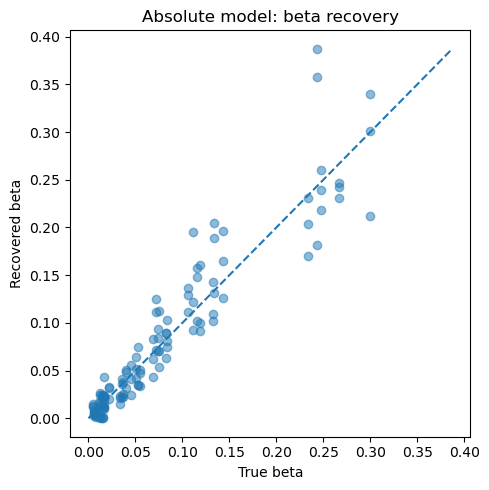

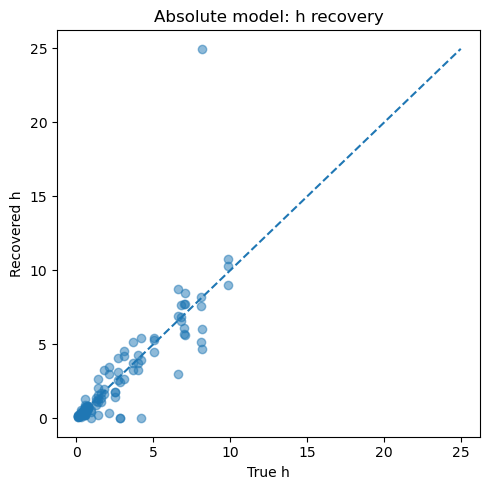

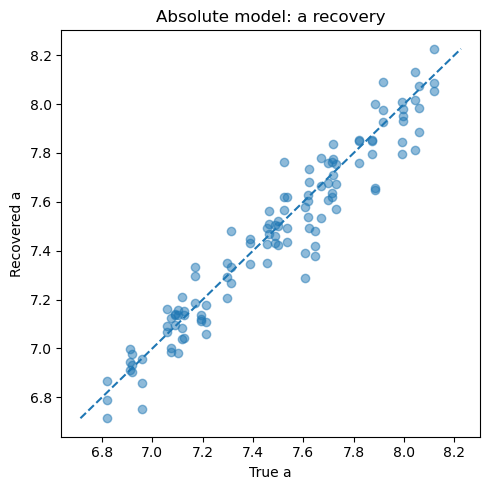

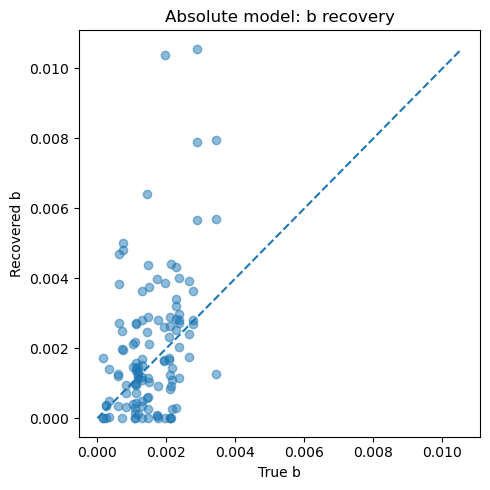

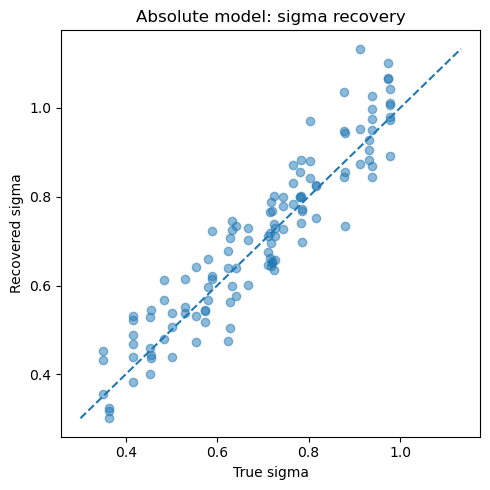

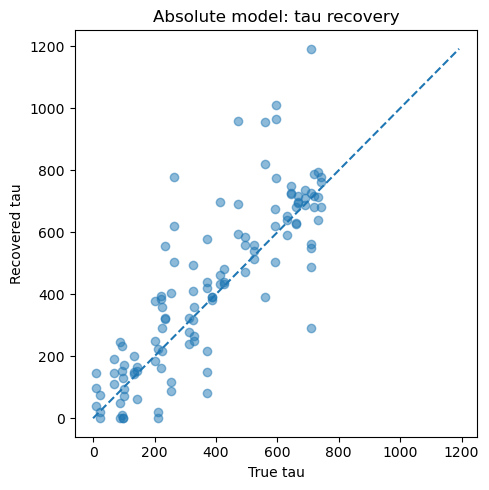

In [73]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        abs_recovery,
        true_col,
        recovered_col,
        parameter,
        "Absolute model"
    )

## 7.4. Squared RT Recovery

In [74]:
SQD_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (6.8, 8.2),
    "b": (0.0, 0.00012),
    "sigma": (0.35, 1.0),
    "tau": (0.0, 750.0)
}

sqd_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, SQD_RECOVERY_RANGES)

In [75]:
sqd_recovery = run_full_model_recovery(
    recovery_template,
    sqd_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_squared,
    "squared"
)
print(f"Successful recovery runs: {len(sqd_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [76]:
sqd_recovery_metrics = summarize_recovery_metrics(sqd_recovery)
sqd_recovery_metrics

,bias,rmse,correlation,parameter
0,0.007714,0.027320,0.955874,beta
1,0.223295,2.577153,0.814489,h
2,-0.030300,0.106680,0.961402,a
3,-0.000005,0.000063,0.454821,b
4,0.044057,0.173960,0.748416,sigma
5,-20.580105,162.014276,0.763704,tau


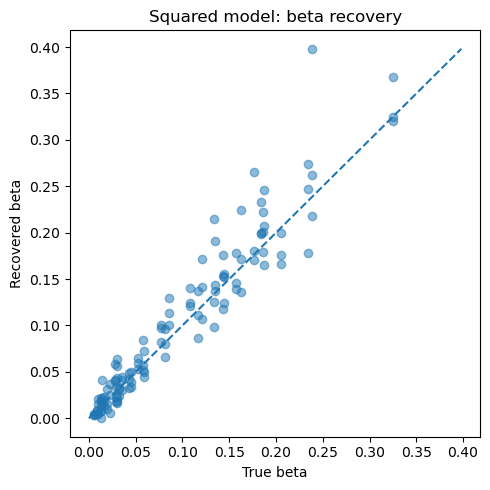

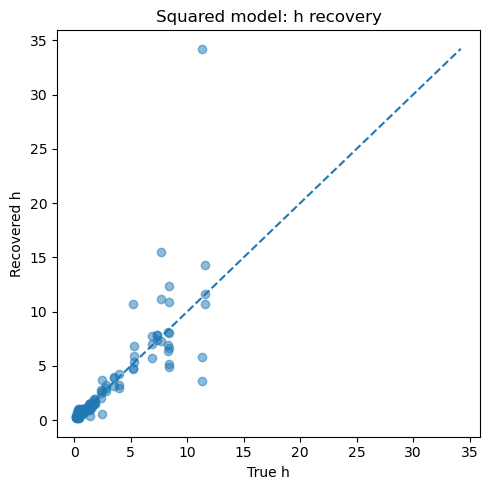

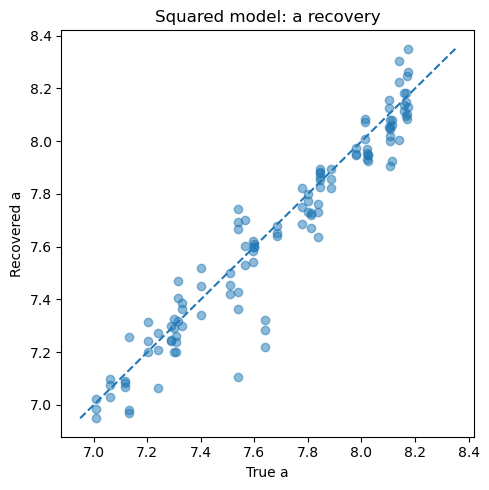

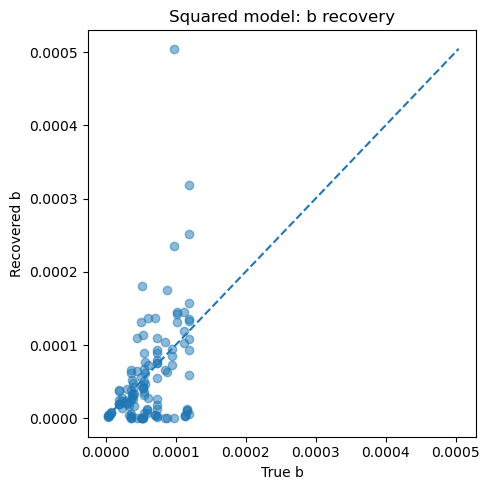

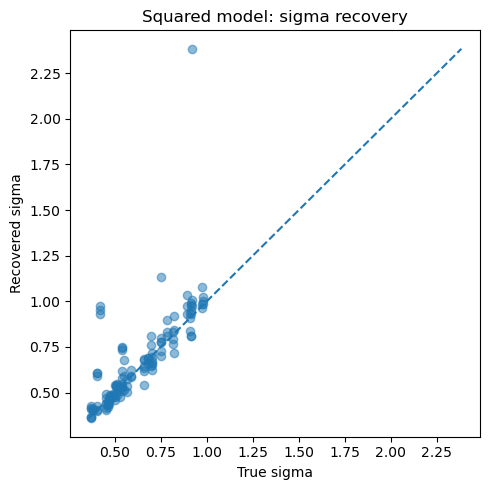

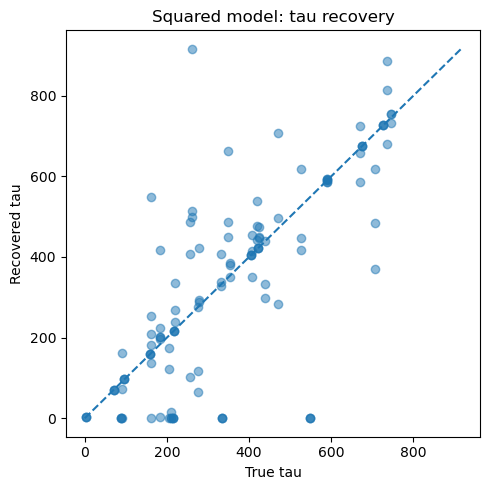

In [77]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        sqd_recovery,
        true_col,
        recovered_col,
        parameter,
        "Squared model"
    )

## 7.5. Exponential RT Recovery

In [78]:
EXP_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (6.8, 8.2),
    "b": (0.0, 0.35),
    "sigma": (0.35, 1.0),
    "tau": (0.0, 750.0)
}

exp_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, EXP_RECOVERY_RANGES)

In [79]:
exp_recovery = run_full_model_recovery(
    recovery_template,
    exp_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_exponential,
    "exponential"
)
print(f"Successful recovery runs: {len(exp_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [80]:
exp_recovery_metrics = summarize_recovery_metrics(exp_recovery)
exp_recovery_metrics

,bias,rmse,correlation,parameter
0,0.008284,0.043213,0.950002,beta
1,0.637439,8.197392,0.524626,h
2,-0.021936,0.112668,0.957746,a
3,0.032343,0.144445,0.494440,b
4,0.007824,0.067391,0.950970,sigma
5,25.321559,155.602307,0.826868,tau


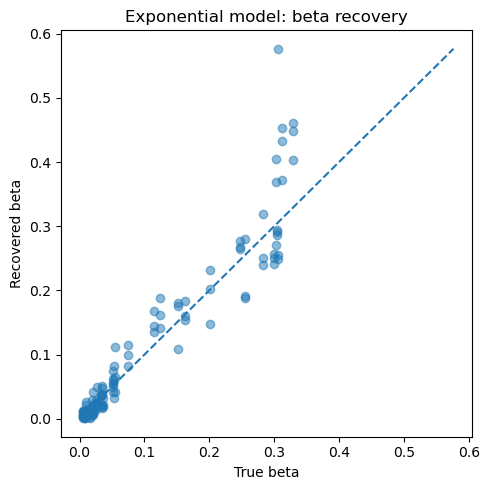

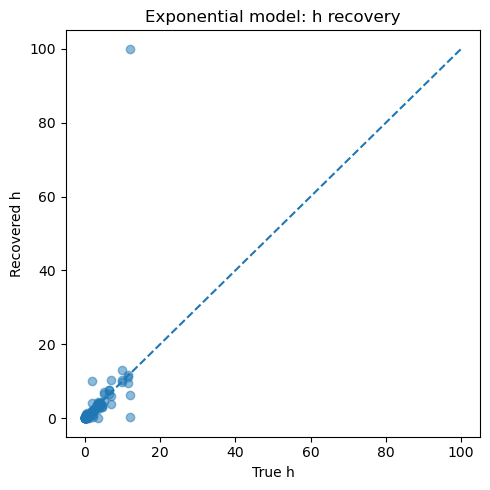

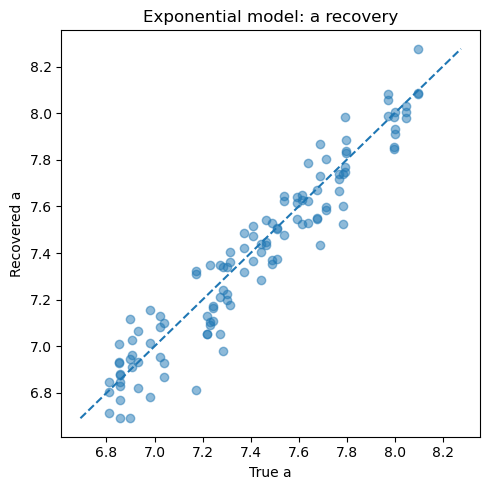

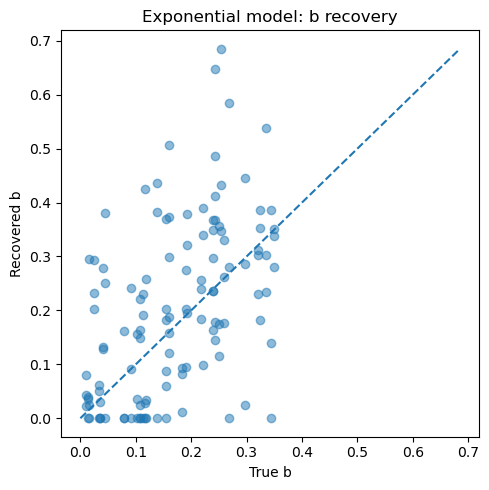

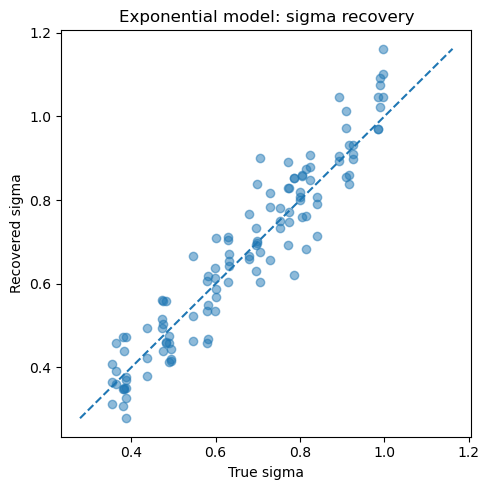

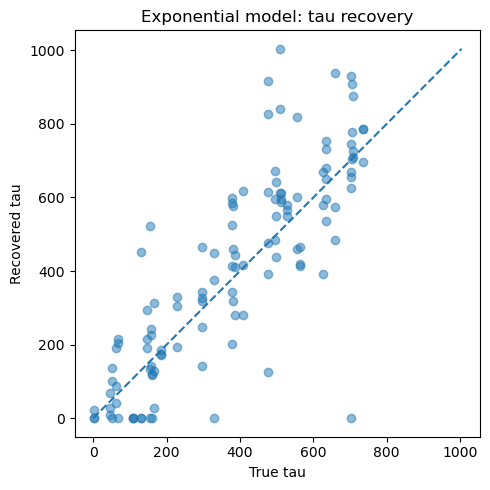

In [81]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        exp_recovery,
        true_col,
        recovered_col,
        parameter,
        "Exponential model"
    )

## 7.6. Does RT Improve Identifiability?

The same simulated choices are fitted once with the full choice + RT model and once with the choice-only baseline. The comparison is restricted to the shared parameters beta and h.

In [82]:
# Compare full vs choice-only recovery within each RT model
abs_choice_vs_full = compare_choice_and_full_recovery(abs_recovery)
abs_choice_vs_full["model"] = "absolute"

sqd_choice_vs_full = compare_choice_and_full_recovery(sqd_recovery)
sqd_choice_vs_full["model"] = "squared"

exp_choice_vs_full = compare_choice_and_full_recovery(exp_recovery)
exp_choice_vs_full["model"] = "exponential"

# Combine all three comparisons into one common summary table
choice_vs_full_recovery = pd.concat([
    abs_choice_vs_full, sqd_choice_vs_full, exp_choice_vs_full], ignore_index=True)

# Report recovery error for the shared beta and h parameters
choice_vs_full_recovery[["model", "parameter", "full_rmse", "choice_rmse", "full_mae", "choice_mae"]]

,model,parameter,full_rmse,choice_rmse,full_mae,choice_mae
0,absolute,beta,0.028661,0.028486,0.018021,0.018316
1,absolute,h,1.819509,8.675329,0.699235,1.447633
2,squared,beta,0.027320,0.027261,0.017495,0.017489
3,squared,h,2.577153,8.620530,0.860982,1.621871
4,exponential,beta,0.043213,0.043516,0.023991,0.024336
5,exponential,h,8.197392,8.239643,1.376428,1.530455


# 8. Test-Retest Reliability

## 8.1. Independent Run B Fits

In [83]:
def fit_model_run_b(fit_function, parameter_names, model_name):
    """Fit one model independently to Run B for all participants."""

    results = []

    for i, file in enumerate(mat_files):
        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        # Fit the model to Run B
        best_result, all_results = fit_function(data_run_b)

        # Count valid optimization starts
        n_successful = sum(
            is_valid_optimization_result(result)
            for result in all_results
        )

        row = {
            "participant": file.stem,
            "model": model_name,
            "fit_success": best_result is not None,
            "successful_starts": n_successful,
            "total_starts": len(all_results)
        }

        # Store parameter estimates if fitting succeeded
        if best_result is not None:
            row["nll"] = best_result.fun

            for name, value in zip(parameter_names, best_result.x):
                row[name] = value

        results.append(row)

        print(f"[{i + 1}/{len(mat_files)}] {model_name} Run B: {file.stem}")

    return pd.DataFrame(results)

In [84]:
# Run choice-only model
run_b_choice = fit_model_run_b(
    fit_choice_only, 
    CHOICE_PARAMETERS, 
    "choice_only"
)

[1/49] choice_only Run B: 2rrjzhgj9
[2/49] choice_only Run B: 3lmzwis6r
[3/49] choice_only Run B: 4f8msviwg
[4/49] choice_only Run B: 52b64k0rp
[5/49] choice_only Run B: 5wlmihb4c
[6/49] choice_only Run B: 6owg3par9
[7/49] choice_only Run B: 8py7pm5i0
[8/49] choice_only Run B: 95vrrzevd
[9/49] choice_only Run B: bh348lli7
[10/49] choice_only Run B: c0ry57ax9
[11/49] choice_only Run B: ck5f3lx8c
[12/49] choice_only Run B: ctdyczfpw
[13/49] choice_only Run B: dasemqdsv
[14/49] choice_only Run B: derouhkrw
[15/49] choice_only Run B: dm8t9csqy
[16/49] choice_only Run B: eqi6zanpf
[17/49] choice_only Run B: etxmnk1pg
[18/49] choice_only Run B: goz8d3fp9
[19/49] choice_only Run B: hrqn8w6vu
[20/49] choice_only Run B: ig1j8ozi9
[21/49] choice_only Run B: iogaivfgt
[22/49] choice_only Run B: ir0t9ca41
[23/49] choice_only Run B: jtf46arcd
[24/49] choice_only Run B: kimjztxjq
[25/49] choice_only Run B: kqi5vqk0e
[26/49] choice_only Run B: ljm2sl8s0
[27/49] choice_only Run B: mu73zwng6
[28/49] ch

In [85]:
# Run absolute RT model
run_b_absolute = fit_model_run_b(
    fit_absolute, 
    FULL_PARAMETERS, 
    "absolute"
)

[1/49] absolute Run B: 2rrjzhgj9
[2/49] absolute Run B: 3lmzwis6r
[3/49] absolute Run B: 4f8msviwg
[4/49] absolute Run B: 52b64k0rp
[5/49] absolute Run B: 5wlmihb4c
[6/49] absolute Run B: 6owg3par9
[7/49] absolute Run B: 8py7pm5i0
[8/49] absolute Run B: 95vrrzevd
[9/49] absolute Run B: bh348lli7
[10/49] absolute Run B: c0ry57ax9
[11/49] absolute Run B: ck5f3lx8c
[12/49] absolute Run B: ctdyczfpw
[13/49] absolute Run B: dasemqdsv
[14/49] absolute Run B: derouhkrw
[15/49] absolute Run B: dm8t9csqy
[16/49] absolute Run B: eqi6zanpf
[17/49] absolute Run B: etxmnk1pg
[18/49] absolute Run B: goz8d3fp9
[19/49] absolute Run B: hrqn8w6vu
[20/49] absolute Run B: ig1j8ozi9
[21/49] absolute Run B: iogaivfgt
[22/49] absolute Run B: ir0t9ca41
[23/49] absolute Run B: jtf46arcd
[24/49] absolute Run B: kimjztxjq
[25/49] absolute Run B: kqi5vqk0e
[26/49] absolute Run B: ljm2sl8s0
[27/49] absolute Run B: mu73zwng6
[28/49] absolute Run B: n08qsd76x
[29/49] absolute Run B: nvbinkqjq
[30/49] absolute Run B:

In [86]:
# Run squared RT model
run_b_squared = fit_model_run_b(
    fit_squared, 
    FULL_PARAMETERS, 
    "squared"
)

[1/49] squared Run B: 2rrjzhgj9
[2/49] squared Run B: 3lmzwis6r
[3/49] squared Run B: 4f8msviwg
[4/49] squared Run B: 52b64k0rp
[5/49] squared Run B: 5wlmihb4c
[6/49] squared Run B: 6owg3par9
[7/49] squared Run B: 8py7pm5i0
[8/49] squared Run B: 95vrrzevd
[9/49] squared Run B: bh348lli7
[10/49] squared Run B: c0ry57ax9
[11/49] squared Run B: ck5f3lx8c
[12/49] squared Run B: ctdyczfpw
[13/49] squared Run B: dasemqdsv
[14/49] squared Run B: derouhkrw
[15/49] squared Run B: dm8t9csqy
[16/49] squared Run B: eqi6zanpf
[17/49] squared Run B: etxmnk1pg
[18/49] squared Run B: goz8d3fp9
[19/49] squared Run B: hrqn8w6vu
[20/49] squared Run B: ig1j8ozi9
[21/49] squared Run B: iogaivfgt
[22/49] squared Run B: ir0t9ca41
[23/49] squared Run B: jtf46arcd
[24/49] squared Run B: kimjztxjq
[25/49] squared Run B: kqi5vqk0e
[26/49] squared Run B: ljm2sl8s0
[27/49] squared Run B: mu73zwng6
[28/49] squared Run B: n08qsd76x
[29/49] squared Run B: nvbinkqjq
[30/49] squared Run B: o7piq7dwr
[31/49] squared Run

In [87]:
# Run exponential RT model
run_b_exponential = fit_model_run_b(
    fit_exponential, 
    FULL_PARAMETERS, 
    "exponential"
)

[1/49] exponential Run B: 2rrjzhgj9
[2/49] exponential Run B: 3lmzwis6r
[3/49] exponential Run B: 4f8msviwg
[4/49] exponential Run B: 52b64k0rp
[5/49] exponential Run B: 5wlmihb4c
[6/49] exponential Run B: 6owg3par9
[7/49] exponential Run B: 8py7pm5i0
[8/49] exponential Run B: 95vrrzevd
[9/49] exponential Run B: bh348lli7
[10/49] exponential Run B: c0ry57ax9
[11/49] exponential Run B: ck5f3lx8c
[12/49] exponential Run B: ctdyczfpw
[13/49] exponential Run B: dasemqdsv
[14/49] exponential Run B: derouhkrw
[15/49] exponential Run B: dm8t9csqy
[16/49] exponential Run B: eqi6zanpf
[17/49] exponential Run B: etxmnk1pg
[18/49] exponential Run B: goz8d3fp9
[19/49] exponential Run B: hrqn8w6vu
[20/49] exponential Run B: ig1j8ozi9
[21/49] exponential Run B: iogaivfgt
[22/49] exponential Run B: ir0t9ca41
[23/49] exponential Run B: jtf46arcd
[24/49] exponential Run B: kimjztxjq
[25/49] exponential Run B: kqi5vqk0e
[26/49] exponential Run B: ljm2sl8s0
[27/49] exponential Run B: mu73zwng6
[28/49] ex

In [88]:
print(f"Choice-only Run B: {run_b_choice['fit_success'].sum()} / {len(run_b_choice)}")
print(f"Absolute Run B: {run_b_absolute['fit_success'].sum()} / {len(run_b_absolute)}")
print(f"Squared Run B: {run_b_squared['fit_success'].sum()} / {len(run_b_squared)}")
print(f"Exponential Run B: {run_b_exponential['fit_success'].sum()} / {len(run_b_exponential)}")

Choice-only Run B: 49 / 49
Absolute Run B: 49 / 49
Squared Run B: 49 / 49
Exponential Run B: 49 / 49


## 8.2. h Boundary Diagnostic

In [89]:
def count_h_boundaries(results, h_max=H_MAX, atol=1e-4):
    """Summarize lower- and upper-bound behavior of h estimates."""
    return pd.Series({
        "n_participants": len(results),
        "h_near_zero": np.isclose(results["h"], 0, atol=atol).sum(),
        "h_near_upper_bound": np.isclose(results["h"], h_max, atol=atol).sum(),
        "h_max_observed": results["h"].max()
    })

In [90]:
# Check h-boundary behavior for all models fitted to Run A
print("Run A")
display(pd.DataFrame({
    "choice_only": count_h_boundaries(run_a_choice),
    "absolute": count_h_boundaries(run_a_absolute),
    "squared": count_h_boundaries(run_a_squared),
    "exponential": count_h_boundaries(run_a_exponential),
}).T)

# Check h-boundary behavior for all models fitted to Run B
print("Run B")
display(pd.DataFrame({
    "choice_only": count_h_boundaries(run_b_choice),
    "absolute": count_h_boundaries(run_b_absolute),
    "squared": count_h_boundaries(run_b_squared),
    "exponential": count_h_boundaries(run_b_exponential),
}).T)

Run A


,n_participants,h_near_zero,h_near_upper_bound,h_max_observed
choice_only,49.0,0.0,2.0,100.000000
absolute,49.0,2.0,0.0,10.284476
squared,49.0,0.0,0.0,10.510222
exponential,49.0,0.0,0.0,10.742644


Run B


,n_participants,h_near_zero,h_near_upper_bound,h_max_observed
choice_only,49.0,2.0,6.0,100.0
absolute,49.0,3.0,4.0,100.0
squared,49.0,2.0,7.0,100.0
exponential,49.0,3.0,4.0,100.0


## 8.3. Test-Retest Reliability

### 8.3.1. Pearson reliability

In [91]:
def compute_test_retest_reliability(run_a, run_b, parameter_names, model_name):
    """Compute Run A vs Run B parameter reliability across participants."""
    # Match Run A and Run B estimates belonging to the same participant
    merged = run_a.merge(run_b, on="participant", suffixes=("_a", "_b"))

    reliability_results = []

    # Evaluate test-retest reliability separately for each model parameter
    for parameter in parameter_names:
        a = merged[f"{parameter}_a"]
        b = merged[f"{parameter}_b"]

        # Use only participants with finite estimates in both runs
        valid = np.isfinite(a) & np.isfinite(b)

        # Pearson correlation quantifies across-participant stability from A to B
        r, p = pearsonr(a[valid], b[valid])

        reliability_results.append({
            "model": model_name,
            "parameter": parameter,
            "n": valid.sum(),
            "correlation": r,
            "p_value": p
        })

    return pd.DataFrame(reliability_results), merged

In [92]:
# Compute reliability of the shared choice-only parameters
choice_reliability, choice_ab = compute_test_retest_reliability(run_a_choice, run_b_choice, CHOICE_PARAMETERS, "choice_only")
choice_reliability

,model,parameter,n,correlation,p_value
0,choice_only,beta,49,0.824723,3.227592e-13
1,choice_only,h,49,-0.001369,9.925530e-01


In [93]:
# Absolute reliability
abs_reliability, abs_ab = compute_test_retest_reliability(run_a_absolute, run_b_absolute, FULL_PARAMETERS, "absolute")
abs_reliability

,model,parameter,n,correlation,p_value
0,absolute,beta,49,0.825995,2.760724e-13
1,absolute,h,49,0.287299,4.532863e-02
2,absolute,a,49,0.747549,6.783305e-10
3,absolute,b,49,0.032891,8.224816e-01
4,absolute,sigma,49,0.658960,2.635740e-07
5,absolute,tau,49,0.394404,5.043872e-03


In [94]:
# Squared reliability
sqd_reliability, sqd_ab = compute_test_retest_reliability(run_a_squared, run_b_squared, FULL_PARAMETERS, "squared")
sqd_reliability

,model,parameter,n,correlation,p_value
0,squared,beta,49,0.826428,2.616744e-13
1,squared,h,49,0.421544,2.556380e-03
2,squared,a,49,0.748955,6.051872e-10
3,squared,b,49,-0.080295,5.833877e-01
4,squared,sigma,49,0.665269,1.841960e-07
5,squared,tau,49,0.390594,5.524656e-03


In [95]:
# Exponential reliability
exp_reliability, exp_ab = compute_test_retest_reliability(run_a_exponential, run_b_exponential, FULL_PARAMETERS, "exponential")
exp_reliability

,model,parameter,n,correlation,p_value
0,exponential,beta,49,0.823026,3.967616e-13
1,exponential,h,49,0.457845,9.401837e-04
2,exponential,a,49,0.755433,3.542603e-10
3,exponential,b,49,0.357322,1.171865e-02
4,exponential,sigma,49,0.660069,2.476295e-07
5,exponential,tau,49,0.394154,5.074289e-03


### 8.3.2. Spearman robustness check

In [96]:
def compute_spearman_reliability(run_a, run_b, parameter_names, model_name):
    """Compute Spearman Run A vs Run B parameter reliability."""
    merged = run_a.merge(run_b, on="participant", suffixes=("_a", "_b"))

    results = []
    for parameter in parameter_names:
        a = merged[f"{parameter}_a"]
        b = merged[f"{parameter}_b"]

        valid = np.isfinite(a) & np.isfinite(b)

        rho, p = spearmanr(a[valid], b[valid])

        results.append({
            "model": model_name,
            "parameter": parameter,
            "n": valid.sum(),
            "spearman_rho": rho,
            "p_value": p
        })

    return pd.DataFrame(results)

In [97]:
choice_spearman = compute_spearman_reliability(run_a_choice, run_b_choice, CHOICE_PARAMETERS, "choice_only")
abs_spearman = compute_spearman_reliability(run_a_absolute, run_b_absolute, CHOICE_PARAMETERS, "absolute")
sqd_spearman = compute_spearman_reliability(run_a_squared, run_b_squared, CHOICE_PARAMETERS, "squared")
exp_spearman = compute_spearman_reliability(run_a_exponential, run_b_exponential, CHOICE_PARAMETERS, "exponential")

reliability_spearman = pd.concat([choice_spearman, abs_spearman, sqd_spearman, exp_spearman], ignore_index=True)
reliability_spearman

,model,parameter,n,spearman_rho,p_value
0,choice_only,beta,49,0.633142,0.000001
1,choice_only,h,49,0.431172,0.001981
2,absolute,beta,49,0.590657,0.000008
3,absolute,h,49,0.338905,0.017216
4,squared,beta,49,0.630644,0.000001
5,squared,h,49,0.581810,0.000012
6,exponential,beta,49,0.624100,0.000002
7,exponential,h,49,0.613540,0.000003


## 8.4. Reliability Plots

In [98]:
def plot_test_retest_reliability(merged_data, parameter, model_name):
    """Plot Run A vs Run B parameter estimates."""
    x = merged_data[f"{parameter}_a"]
    y = merged_data[f"{parameter}_b"]

    # Exclude participants without finite estimates in either run
    valid = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(5, 5))
    plt.scatter(x[valid], y[valid])

    limits = [min(x[valid].min(), y[valid].min()),
              max(x[valid].max(), y[valid].max())]

    plt.plot(limits, limits, "--")
    plt.xlabel(f"Run A {parameter}")
    plt.ylabel(f"Run B {parameter}")
    plt.title(f"{model_name}: {parameter} reliability")
    plt.tight_layout()
    plt.show()

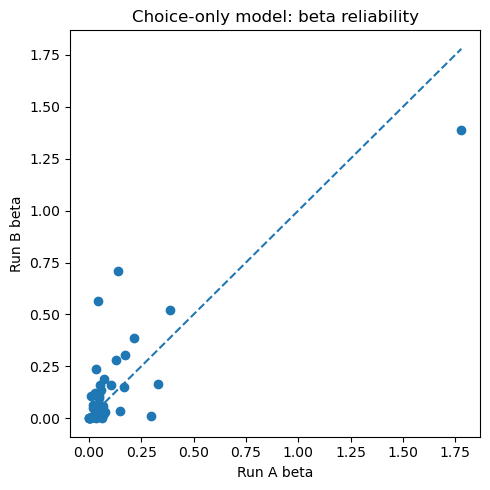

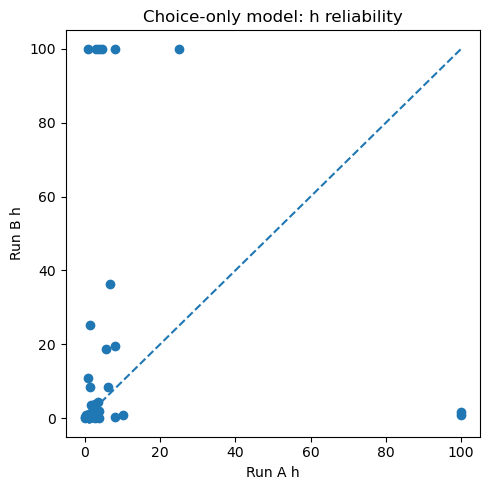

In [99]:
# Choice-only
for parameter in CHOICE_PARAMETERS:
    plot_test_retest_reliability(choice_ab, parameter, "Choice-only model")

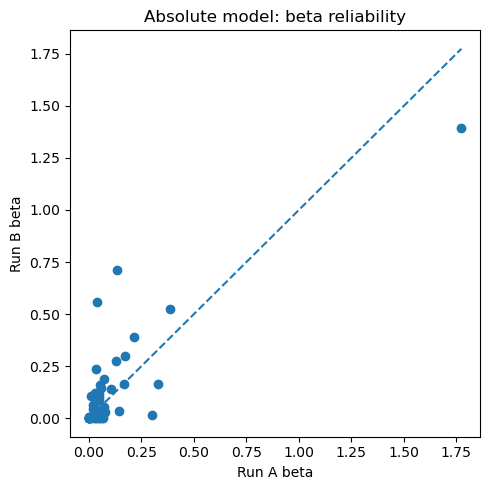

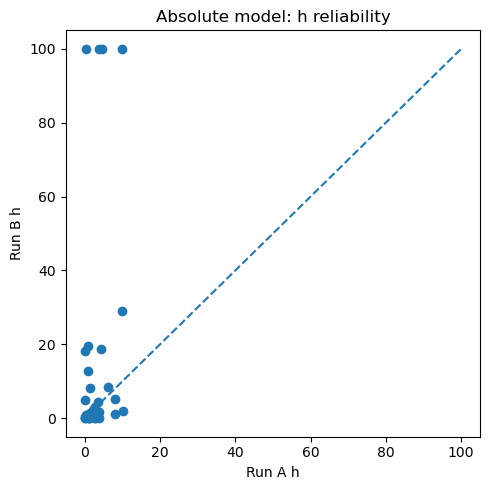

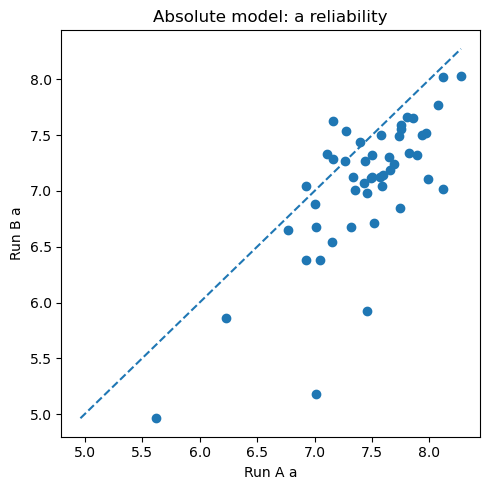

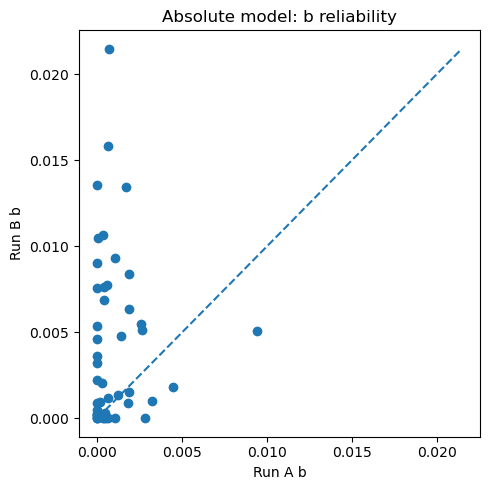

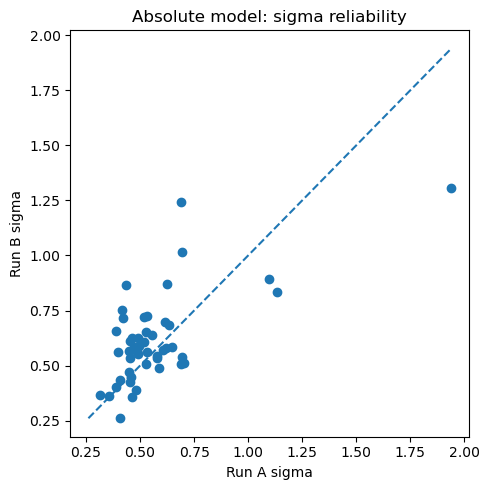

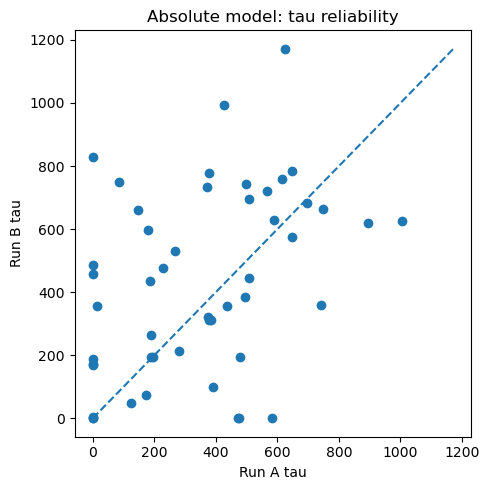

In [100]:
# Absolute
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(abs_ab, parameter, "Absolute model")

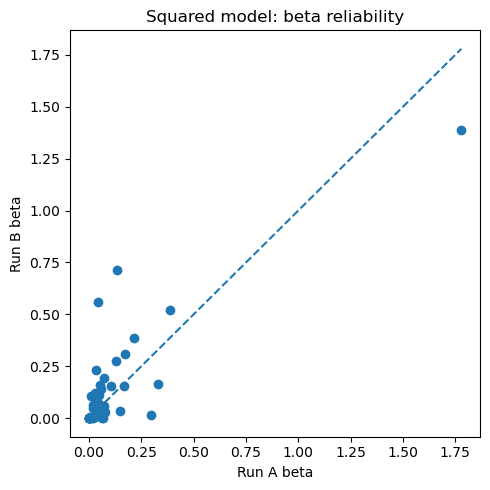

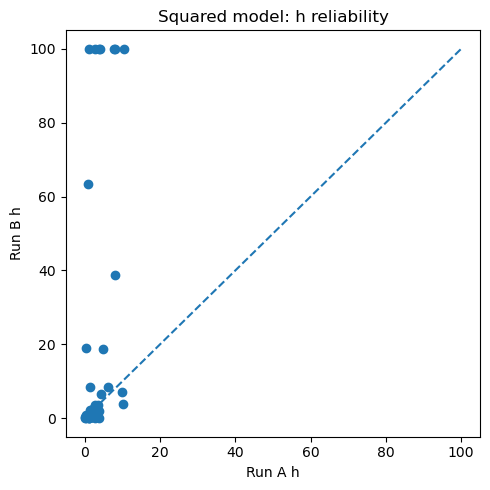

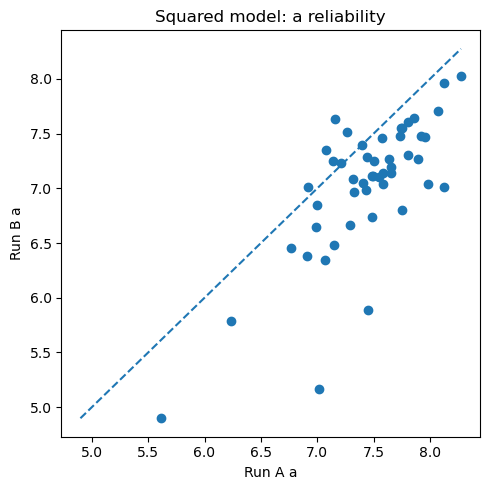

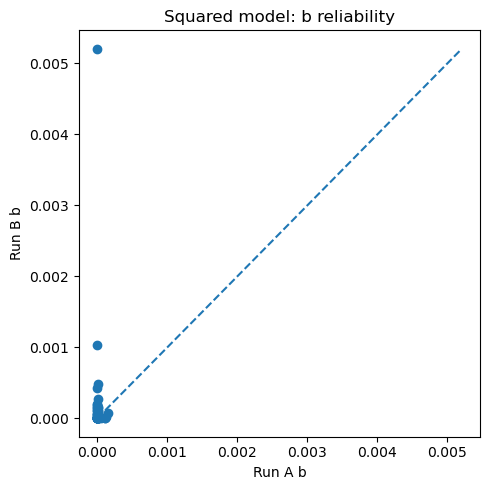

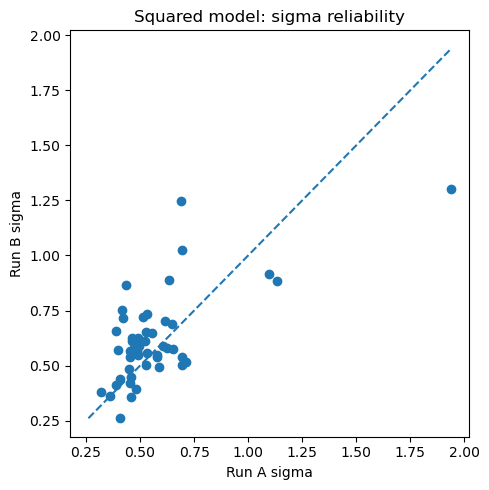

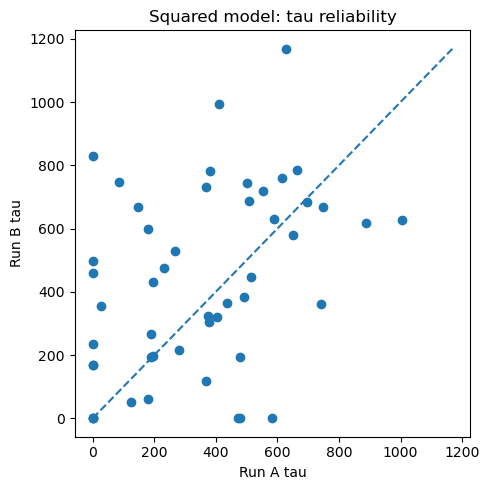

In [101]:
# Squared
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(sqd_ab, parameter, "Squared model")

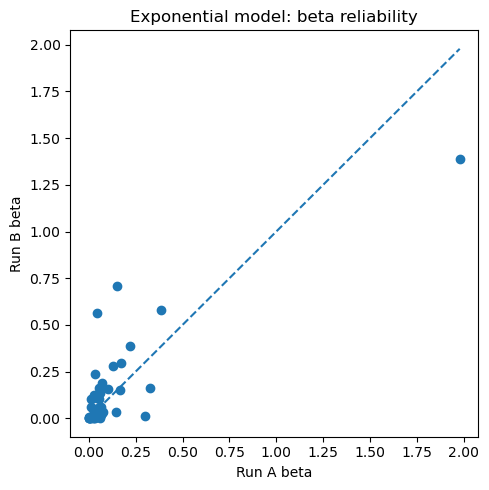

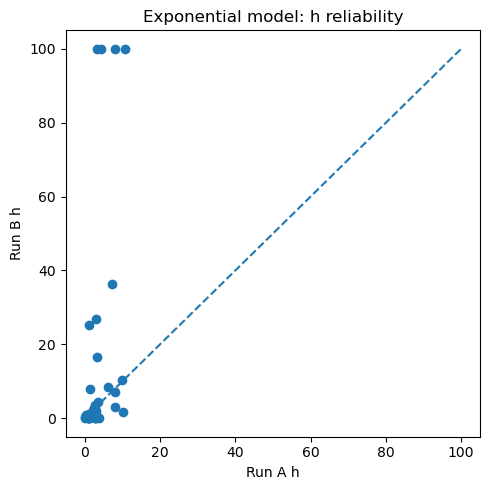

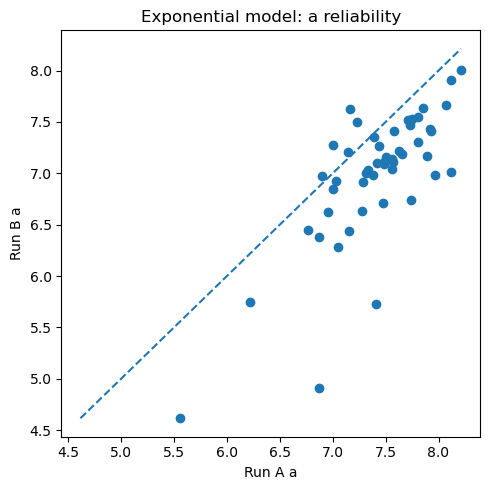

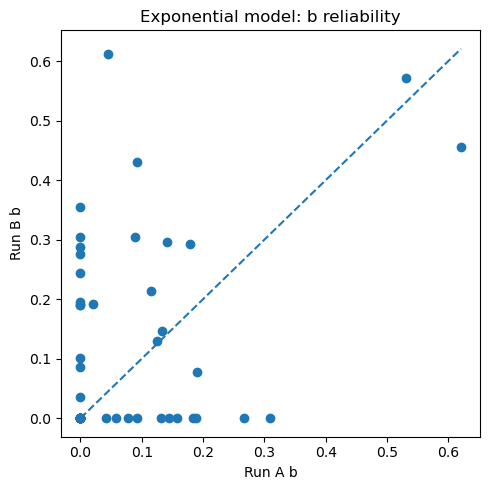

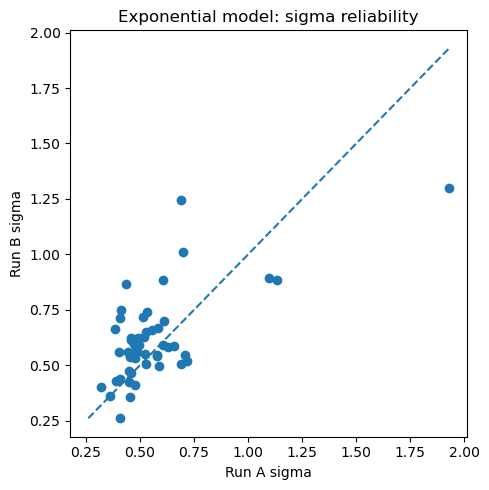

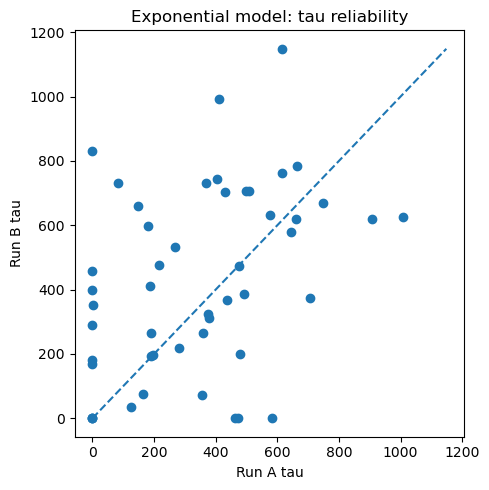

In [102]:
# Exponential
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(exp_ab, parameter, "Exponential model")

## 8.5. Does RT Improve Reliability?

Reliability of the shared $\beta$ and $h$ parameters is compared between the choice-only baseline and each full RT model.

In [103]:
# Start with choice-only reliability for the shared beta and h parameters
reliability_comparison = (
    choice_reliability[["parameter", "correlation"]]
    .rename(columns={"correlation": "choice_only_r"})
    .merge(abs_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "absolute_r"})
    .merge(sqd_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "squared_r"})
    .merge(exp_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "exponential_r"})
)

# Express the RT-related change as full-model-r - choice-model-r
for model_name in ["absolute", "squared", "exponential"]:
    reliability_comparison[f"{model_name}_difference"] = (reliability_comparison[f"{model_name}_r"] - reliability_comparison["choice_only_r"])

reliability_comparison

,parameter,choice_only_r,absolute_r,squared_r,exponential_r,absolute_difference,squared_difference,exponential_difference
0,beta,0.824723,0.825995,0.826428,0.823026,0.001272,0.001706,-0.001696
1,h,-0.001369,0.287299,0.421544,0.457845,0.288667,0.422912,0.459214


# 9. Out-of-Sample Prediction

Parameters estimated from Run A are held fixed and used to predict behavior in Run B. Choice and RT prediction are evaluated separately for reward and loss trials.

## 9.1. Shared Predictive Utilities

In [104]:
CONDITION_LABELS = {
    1.0: "reward",
    2.0: "loss"
}

In [105]:
def choice_log_likelihood_per_trial(y, pi):
    """Compute Bernoulli choice log-likelihood for each trial."""
    
    # Avoid log(0)
    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    return (y * np.log(pi) + (1 - y) * np.log(1 - pi))

In [106]:
def evaluate_choice_prediction(data, beta, h):
    """Evaluate held-out choice prediction for one participant."""
    r_cert, r_uncert, p, y, _, condition = prepare_data(data)
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    delta_v = compute_value_difference(v_cert, v_uncert)
    pi = compute_choice_probability(delta_v, beta)

    # Evaluate probabilistic prediction using trial-wise choice log-likelihood
    trial_ll = choice_log_likelihood_per_trial(y, pi)

    # Convert probabilities to binary predictions for descriptive accuracy
    prediction = (pi >= 0.5).astype(int)
    correct = (prediction == y).astype(float)

    return pd.DataFrame({
        "choice_ll": trial_ll,
        "choice_correct": correct,
        "condition": condition
    })

In [107]:
def evaluate_choice_oos_all(fit_results, model_name):
    """Evaluate Run A choice parameters on Run B for all participants."""
    trial_results = []

    # Apply each participant's Run A estimates to that participant's Run B trials
    for file in mat_files:
        participant_id = file.stem
        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        # Retrieve the corresponding participant-level Run A parameter estimates
        row = fit_results.loc[fit_results["participant"] == participant_id].iloc[0]
        
        # Generate held-out choice predictions without refitting on Run B
        participant_results = evaluate_choice_prediction(data_run_b, row["beta"], row["h"])
        participant_results["participant"] = participant_id
        participant_results["model"] = model_name

        trial_results.append(participant_results)

    return pd.concat(trial_results, ignore_index=True)

In [108]:
def summarize_choice_oos(trial_results):
    """Summarize held-out choice performance by participant and condition."""
    summary = (
        trial_results
        .groupby(["participant", "model", "condition"], as_index=False)
        .agg(
            choice_ll=("choice_ll", "mean"), 
            choice_accuracy=("choice_correct", "mean"), 
            n_trials=("choice_ll", "size")
        )
    )

    summary["condition_label"] = summary["condition"].map(CONDITION_LABELS)

    return summary

In [109]:
def compare_choice_oos_to_baseline(choice_summary, full_model, baseline_model="choice_only"):
    """Compare one full model with the choice-only baseline on Run B choices."""

    # Keep only the full model and choice-only baseline being compared
    subset = choice_summary[choice_summary["model"].isin([baseline_model, full_model])]

    # Place both models side by side for each participant and condition
    comparison = (subset.pivot(
        index=["participant", "condition_label"], 
        columns="model", 
        values=["choice_ll", "choice_accuracy"]
    ).reset_index())

    # Flatten the MultiIndex column names created by pivot()
    comparison.columns = [
        "_".join(str(x) for x in col if str(x) != "")
        if isinstance(col, tuple)
        else col
        for col in comparison.columns
    ]

    # Positive differences indicate better choice prediction by the full model
    comparison["ll_difference"] = (
        comparison[f"choice_ll_{full_model}"]
        - comparison[f"choice_ll_{baseline_model}"]
    )

    comparison["accuracy_difference"] = (
            comparison[f"choice_accuracy_{full_model}"]
            - comparison[f"choice_accuracy_{baseline_model}"]
        )

    # Describe participant-level differences separately for reward and loss
    difference_summary = (
        comparison.groupby("condition_label")[["ll_difference", "accuracy_difference"]]
        .agg(["mean", "median", "std"])
    )

    test_rows = []

    # Test paired choice log-likelihood differences within each condition
    for condition in ["reward", "loss"]:
        ll_diff = comparison.loc[comparison["condition_label"] == condition, "ll_difference"].dropna()

        statistic, p_value=wilcoxon(ll_diff)

        test_rows.append({
            "condition": condition,
            "n": len(ll_diff),
            "mean_difference": ll_diff.mean(),
            "median_difference": ll_diff.median(),
            "wilcoxon_statistic": statistic,
            "p_value": p_value
        })

    tests = pd.DataFrame(test_rows)
    
    return comparison, difference_summary, tests

In [110]:
def shifted_lognormal_log_likelihood_per_trial(rt, mu, sigma, tau):
    """Compute shifted log-normal log-likelihood for each trial."""

    # Invalid distribution parameters make all trial likelihoods undefined
    if sigma <= 0 or tau < 0:
        return np.full(len(rt), -np.inf)

    # Apply the fitted non-decision-time shift to the held-out RTs
    rt_shifted = rt - tau

    # Initialize unsupported trials with negative infinite log-likelihood
    ll  = np.full(len(rt), -np.inf)

    # The shifted log-normal model only supports RT > tau
    valid = rt_shifted > 0

    log_rt = np.log(rt_shifted[valid])

    # Evaluate the RT likelihood only for trials inside the model support
    ll[valid] = (
        -np.log(rt_shifted[valid])
        -np.log(sigma)
        -0.5 * np.log(2 * np.pi)
        -((log_rt - mu[valid]) ** 2)
        / (2 * sigma ** 2)
    )

    return ll

In [111]:
def expected_rt_shifted_lognormal(mu, sigma, tau):
    """Predictive mean RT under the shifted log-normal model."""
    return tau + np.exp(mu + 0.5 * sigma ** 2)

def median_rt_shifted_lognormal(mu, tau):
    """Predictive median RT under the shifted log-normal model."""
    return tau + np.exp(mu)

In [112]:
def compute_rt_mu(delta_v, a, b, model_name):
    """Compute trial-wise log-RT location for each RT model."""
    if model_name == "absolute":
        return a - b * np.abs(delta_v)
    elif model_name == "squared":
        return a - b * (delta_v ** 2)
    elif model_name == "exponential":
        return a + b * np.exp(-(delta_v ** 2))
    else:
        raise ValueError(f"Unknown RT model: {model_name}")

In [113]:
def evaluate_rt_prediction(data, h, a, b, sigma, tau, model_name):
    """
    Evaluate held-out RT prediction for one participant.
    
    RT predictive log-likelihood evaluates the full predictive distribution.

    MAE is computed from the predictive median, which is the point prediction 
    naturally associated with absolute-error loss.

    Predictive mean is retained as an additional descriptive quantity.
    """

    r_cert, r_uncert, p, _, rt, condition = prepare_data(data)
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    
    delta_v = compute_value_difference(v_cert, v_uncert)
    mu = compute_rt_mu(delta_v, a, b, model_name)

    # Full predictive distribution
    rt_ll = shifted_lognormal_log_likelihood_per_trial(rt, mu, sigma, tau)

    # Point predictions
    predicted_rt_median = median_rt_shifted_lognormal(mu, tau)
    predicted_rt_mean = expected_rt_shifted_lognormal(mu, sigma, tau)

    # MAE is based on the predictive median
    rt_absolute_error = np.abs(predicted_rt_median - rt)

    # Supplementary squared-error metric
    rt_squared_error = (predicted_rt_mean - rt) ** 2

    return pd.DataFrame({
        "rt": rt,
        "predicted_rt_median": predicted_rt_median,
        "predicted_rt_mean": predicted_rt_mean,
        "rt_ll": rt_ll,
        "rt_absolute_error": rt_absolute_error,
        "rt_squared_error": rt_squared_error,
        "condition": condition,
        "support_violation": rt <= tau
    })

In [114]:
def evaluate_rt_oos_all(fit_results, model_name):
    """Evaluate Run A RT parameters on Run B for all participants."""
    trial_results = []

    # Apply each participant's Run A RT parameters to their Run B trials
    for file in mat_files:
        participant_id = file.stem

        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        row = fit_results.loc[fit_results["participant"] == participant_id].iloc[0]

        # Predict Run B RTs without updating any parameters
        participant_results = evaluate_rt_prediction(
            data_run_b, row["h"], row["a"], row["b"], row["sigma"], row["tau"], model_name
        )

        participant_results["participant"] = participant_id
        participant_results["model"] = model_name

        trial_results.append(participant_results)

    return pd.concat(trial_results, ignore_index=True)

In [115]:
def summarize_rt_oos(trial_results):
    """Summarize held-out RT prediction by participant and condition."""
    summary = (
        trial_results
        .groupby(["participant", "model", "condition"], as_index=False)
        .agg(
            rt_ll_sum=("rt_ll", "sum"),
            rt_ll_mean=("rt_ll", "mean"),

            rt_mae=("rt_absolute_error", "mean"), 
            rt_mse=("rt_squared_error", "mean"),

            mean_rt=("rt", "mean"),
            mean_predicted_rt_median=("predicted_rt_median", "mean"),
            mean_predicted_rt_mean=("predicted_rt_mean", "mean"), 
            n_trials=("rt", "size"),
            n_support_violations=("support_violation", "sum")
        )
    )
    summary["rt_rmse"] = np.sqrt(summary["rt_mse"])
    summary["condition_label"] = (summary["condition"].map(CONDITION_LABELS))
    return summary

In [116]:
def summarize_rt_oos_descriptive(rt_summary):
    """Summarize participant-level RT prediction by condition."""
    return (rt_summary.groupby("condition_label")
            .agg(
               rt_ll_sum_mean=("rt_ll_sum", "mean"),
               rt_ll_sum_median=("rt_ll_sum", "median"),
               rt_ll_mean_mean=("rt_ll_mean", "mean"),
               rt_ll_mean_median=("rt_ll_mean", "median"),    

               rt_mae_mean=("rt_mae", "mean"),
               rt_mae_median=("rt_mae", "median"),
               rt_mae_std=("rt_mae", "std"),

               rt_rmse_mean=("rt_rmse", "mean"),
               rt_rmse_median=("rt_rmse", "median"),

               mean_observed_rt=("mean_rt", "mean"),
               mean_predicted_rt_median=("mean_predicted_rt_median", "mean"), 
               mean_predicted_rt_mean=("mean_predicted_rt_mean", "mean"),

               support_violations=("n_support_violations", "sum")
               )
            )

In [117]:
def plot_oos_metric(summary, models, metric, ylabel, title):
    """Plot participant-level OOS performance by model and condition."""
    plot_data = []
    labels = []

    for condition in ["reward", "loss"]:
        for model in models:
            values = summary.loc[
                (summary["condition_label"] == condition)
                & (summary["model"] == model),
                metric
            ].dropna()

            plot_data.append(values)
            labels.append(f"{model}\n{condition}")

    plt.figure(figsize=(10, 5))
    plt.boxplot(plot_data, tick_labels=labels, showmeans=True)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 9.2. Choice Prediction on Run B

In [118]:
# Generate Run B choice predictions from each model's fixed Run A estimates
choice_oos_choice_only = evaluate_choice_oos_all(run_a_choice, "choice_only")
choice_oos_absolute = evaluate_choice_oos_all(run_a_absolute, "absolute")
choice_oos_squared = evaluate_choice_oos_all(run_a_squared, "squared")
choice_oos_exponential = evaluate_choice_oos_all(run_a_exponential, "exponential")

# Combine summaries of all four models 
choice_oos_summary = pd.concat([
    summarize_choice_oos(choice_oos_choice_only),
    summarize_choice_oos(choice_oos_absolute),
    summarize_choice_oos(choice_oos_squared),
    summarize_choice_oos(choice_oos_exponential)
], ignore_index=True)

# Describe held-out choice log-likelihood and accuracy across participants
choice_oos_descriptive = (
    choice_oos_summary.groupby(["model", "condition_label"])
    [["choice_ll", "choice_accuracy"]].agg(["mean", "std"])
)

choice_oos_descriptive

choice_ll           choice_accuracy          
                                 mean       std            mean       std
model       condition_label                                              
absolute    loss            -0.662535  0.063997        0.649091  0.144825
            reward          -0.746081  0.691403        0.648590  0.218822
choice_only loss            -0.670399  0.087960        0.631133  0.171363
            reward          -0.802418  0.770010        0.654304  0.223140
exponential loss            -0.668214  0.083217        0.649501  0.150441
            reward          -0.852088  0.953404        0.663488  0.219511
squared     loss            -0.662196  0.064151        0.641133  0.161402
            reward          -0.757470  0.723510        0.654100  0.215956

### Absolute vs choice-only

In [119]:
(choice_oos_absolute_comparison, 
 choice_oos_absolute_difference, 
 choice_oos_absolute_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="absolute")

display(choice_oos_absolute_difference)
display(choice_oos_absolute_tests)

ll_difference                         accuracy_difference  \
                         mean        median       std                mean   
condition_label                                                             
loss                 0.007864  0.000000e+00  0.055469            0.017957   
reward               0.056338 -2.098798e-08  0.352524           -0.005714   

                                  
                median       std  
condition_label                   
loss               0.0  0.125033  
reward             0.0  0.122950

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,0.056338,-2.098798e-08,503.0,0.518596
1,loss,49,0.007864,0.000000e+00,526.0,0.687594


### Squared vs choice-only

In [120]:
(choice_oos_squared_comparison, 
 choice_oos_squared_difference, 
 choice_oos_squared_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="squared")

display(choice_oos_squared_difference)
display(choice_oos_squared_tests)

ll_difference                         accuracy_difference  \
                         mean        median       std                mean   
condition_label                                                             
loss                 0.008203  2.528178e-08  0.055373            0.010000   
reward               0.044948 -3.963896e-08  0.352673           -0.000204   

                                  
                median       std  
condition_label                   
loss               0.0  0.074162  
reward             0.0  0.097393

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,0.044948,-3.963896e-08,469.0,0.31475
1,loss,49,0.008203,2.528178e-08,506.0,0.53937


### Exponential vs choice-only

In [121]:
(choice_oos_exponential_comparison, 
 choice_oos_exponential_difference, 
 choice_oos_exponential_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="exponential")

display(choice_oos_exponential_difference)
display(choice_oos_exponential_tests)

ll_difference                         accuracy_difference  \
                         mean        median       std                mean   
condition_label                                                             
loss                 0.002186  8.426838e-09  0.012807            0.018367   
reward              -0.049670 -1.338541e-09  0.318215            0.009184   

                                  
                median       std  
condition_label                   
loss               0.0  0.101967  
reward             0.0  0.084996

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,-0.049670,-1.338541e-09,437.0,0.178970
1,loss,49,0.002186,8.426838e-09,378.0,0.049036


### Choice OOS plot

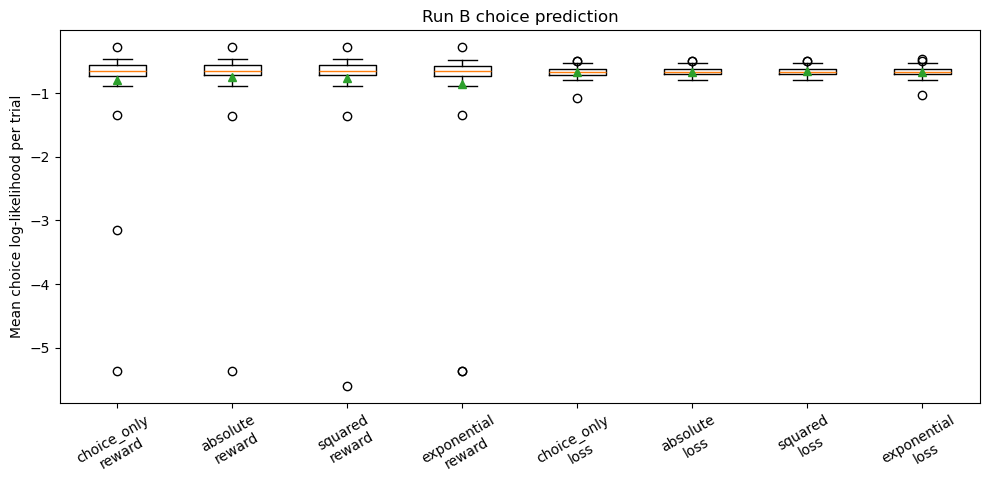

In [122]:
plot_oos_metric(choice_oos_summary,
                models=["choice_only", "absolute", "squared", "exponential"],
                metric="choice_ll",
                ylabel="Mean choice log-likelihood per trial",
                title="Run B choice prediction")

## 9.3. RT Prediction on Run B

### 9.3.1. Generate held-out RT predictions

In [123]:
rt_oos_absolute = evaluate_rt_oos_all(run_a_absolute, "absolute")
rt_oos_squared = evaluate_rt_oos_all(run_a_squared, "squared")
rt_oos_exponential = evaluate_rt_oos_all(run_a_exponential, "exponential")

### 9.3.2. Support coverage and common-support set

In [124]:
def add_rt_trial_id(df):
    out = df.copy()
    out["trial_id"] = out.groupby(["participant", "condition"]).cumcount()
    return out

In [125]:
# Merge three models
rt_abs_with_id = add_rt_trial_id(rt_oos_absolute)
rt_sqd_with_id = add_rt_trial_id(rt_oos_squared)
rt_exp_with_id = add_rt_trial_id(rt_oos_exponential)

rt_oos_all_trials = pd.concat([rt_abs_with_id, rt_sqd_with_id, rt_exp_with_id], ignore_index=True)

# Define common support
trial_support_status = (
    rt_oos_all_trials
    .groupby(["participant", "condition", "trial_id"], as_index=False)
    .agg(any_support_violation=("support_violation", "any")))

rt_oos_all_trials = (
    rt_oos_all_trials
    .merge(trial_support_status, on=["participant", "condition", "trial_id"], how="left")
)

rt_oos_all_trials["common_support"] = ~rt_oos_all_trials["any_support_violation"]

# Result of support coverage
rt_support_coverage = (
    rt_oos_all_trials
    .groupby(["model", "condition"], as_index=False)
    .agg(n_trials=("rt", "size"), n_support_violations=("support_violation", "sum"))
)

rt_support_coverage["support_coverage"] = 1 - rt_support_coverage["n_support_violations"] / rt_support_coverage["n_trials"]
rt_support_coverage["condition_label"] = rt_support_coverage["condition"].map(CONDITION_LABELS)
rt_support_coverage

,model,condition,n_trials,n_support_violations,support_coverage,condition_label
0,absolute,1.0,4894,13,0.997344,reward
1,absolute,2.0,4889,8,0.998364,loss
2,exponential,1.0,4894,13,0.997344,reward
3,exponential,2.0,4889,8,0.998364,loss
4,squared,1.0,4894,13,0.997344,reward
5,squared,2.0,4889,8,0.998364,loss


In [126]:
print("Unique violating Run B trials:", trial_support_status["any_support_violation"].sum())

Unique violating Run B trials: 21


### 9.3.3. Common-support log-likelihood dataset

In [127]:
def summarize_rt_ll_common_support(trial_results):
    summary = (
        trial_results
        .groupby(["participant", "model", "condition"], as_index=False)
        .agg(rt_ll_sum=("rt_ll", "sum"), rt_ll_mean=("rt_ll", "mean"), n_supported_trials=("rt_ll", "size"))
    )

    summary["condition_label"] = summary["condition"].map(CONDITION_LABELS)

    return summary

In [128]:
rt_oos_common_support = rt_oos_all_trials[rt_oos_all_trials["common_support"]].copy()

rt_ll_common_summary = summarize_rt_ll_common_support(rt_oos_common_support)

In [129]:
assert np.isfinite(rt_ll_common_summary["rt_ll_mean"]).all()

### 9.3.4. RT descriptive prediction performance on all Run B trials

In [130]:
rt_oos_absolute_summary = summarize_rt_oos(rt_oos_absolute)
rt_oos_squared_summary = summarize_rt_oos(rt_oos_squared)
rt_oos_exponential_summary = summarize_rt_oos(rt_oos_exponential)

rt_oos_summary = pd.concat([rt_oos_absolute_summary, rt_oos_squared_summary, rt_oos_exponential_summary],
                           ignore_index=True)

In [131]:
rt_oos_absolute_descriptive = summarize_rt_oos_descriptive(rt_oos_absolute_summary)
display(rt_oos_absolute_descriptive)

rt_oos_squared_descriptive = summarize_rt_oos_descriptive(rt_oos_squared_summary)
display(rt_oos_squared_descriptive)

rt_oos_exponential_descriptive = summarize_rt_oos_descriptive(rt_oos_exponential_summary)
display(rt_oos_exponential_descriptive)

,rt_ll_sum_mean,rt_ll_sum_median,rt_ll_mean_mean,rt_ll_mean_median,rt_mae_mean,rt_mae_median,rt_mae_std,rt_rmse_mean,rt_rmse_median,mean_observed_rt,mean_predicted_rt_median,mean_predicted_rt_mean,support_violations
condition_label,,,,,,,,,,,,,
loss,-inf,-834.992392,-inf,-8.370851,832.346043,816.454792,290.099405,1272.156286,1198.413972,2060.173486,2214.881484,2613.776555,8
reward,-inf,-837.188827,-inf,-8.371888,830.877288,805.623123,343.049339,1275.409281,1161.135503,1854.191345,2175.526857,2568.986625,13


,rt_ll_sum_mean,rt_ll_sum_median,rt_ll_mean_mean,rt_ll_mean_median,rt_mae_mean,rt_mae_median,rt_mae_std,rt_rmse_mean,rt_rmse_median,mean_observed_rt,mean_predicted_rt_median,mean_predicted_rt_mean,support_violations
condition_label,,,,,,,,,,,,,
loss,-inf,-837.085112,-inf,-8.379254,832.252862,815.731103,286.897980,1271.364428,1196.520127,2060.173486,2201.554132,2599.244983,8
reward,-inf,-840.077085,-inf,-8.400771,829.932343,800.249829,339.451636,1273.144637,1144.223648,1854.191345,2161.342871,2551.592982,13


,rt_ll_sum_mean,rt_ll_sum_median,rt_ll_mean_mean,rt_ll_mean_median,rt_mae_mean,rt_mae_median,rt_mae_std,rt_rmse_mean,rt_rmse_median,mean_observed_rt,mean_predicted_rt_median,mean_predicted_rt_mean,support_violations
condition_label,,,,,,,,,,,,,
loss,-inf,-828.787725,-inf,-8.296339,825.588943,797.258456,283.500403,1274.176455,1168.035244,2060.173486,2207.917179,2608.93232,8
reward,-inf,-828.860809,-inf,-8.288608,835.814867,804.792573,349.859563,1271.247500,1161.135455,1854.191345,2218.213582,2607.29946,13


### 9.3.5. RT prediction plot

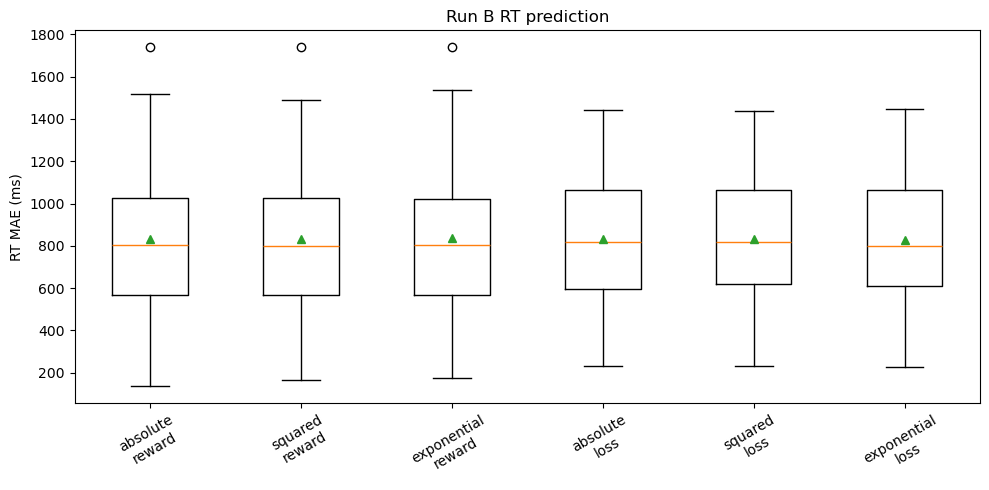

In [159]:
plot_oos_metric(rt_oos_summary, 
                models=["absolute", "squared", "exponential"],
                metric="rt_mae", ylabel="RT MAE (ms)", title="Run B RT prediction")

# 10. Model Comparison & Value of RT

## 10.1. Which RT mapping predicts RT best?

### 10.1.1. Primary comparison: RT predictive log-likelihood

RT models are compared using participant-level mean held-out RT log predictive density on the common-support Run B trials. Higher values indicate better predictive performance. Support coverage is reported separately in section 9.3.2.

In [133]:
def summarize_rt_ll_by_model(rt_summary):
    """Descriptive participant-level RT predictive log-likelihood by model and condition."""

    return (rt_summary
            .groupby(["condition_label", "model"])
            .agg(n_participants=("participant", "nunique"),
                 n_finite=("rt_ll_mean", lambda x: np.isfinite(x).sum()),
                 n_nonfinite=("rt_ll_mean", lambda x: (~np.isfinite(x)).sum()),
                 mean_rt_ll=("rt_ll_mean", lambda x: x[np.isfinite(x)].mean()),
                 median_rt_ll=("rt_ll_mean", lambda x: x[np.isfinite(x)].median()),
                 std_rt_ll=("rt_ll_mean", lambda x: x[np.isfinite(x)].std()))
            .reset_index())

In [134]:
rt_ll_descriptive = summarize_rt_ll_by_model(rt_ll_common_summary)
rt_ll_descriptive

,condition_label,model,n_participants,n_finite,n_nonfinite,mean_rt_ll,median_rt_ll,std_rt_ll
0,loss,absolute,49,49,0,-8.398797,-8.370851,7.299229e-01
1,loss,exponential,49,49,0,-8.347161,-8.296339,6.790699e-01
2,loss,squared,49,49,0,-9.263007,-8.379254,4.723610e+00
3,reward,absolute,49,49,0,-40.675705,-8.294317,1.965278e+02
4,reward,exponential,49,49,0,-8.380288,-8.252420,9.733917e-01
5,reward,squared,49,49,0,-784094.532111,-8.315624,5.255752e+06


In [135]:
def compare_rt_models_friedman_ll(rt_summary):
    """
    Compare participant-level mean RT predictive log-likelihood across RT models.
    Higher RT log-likelihood indicates better prediction.
    If any participant has a non-finite log-likelihood, the inferential test is not run yet.
    Those cases will be handled explicitly in the support-violation analysis.
    """

    rows = []

    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary
            .loc[rt_summary["condition_label"] == condition, ["participant", "model", "rt_ll_mean"]]
            .pivot(index="participant", columns="model", values="rt_ll_mean")
            .dropna())

        required_models = ["absolute", "squared", "exponential"]

        condition_data = condition_data[required_models]

        finite_mask = np.isfinite(condition_data).all(axis=1)

        n_total = len(condition_data)
        n_finite = finite_mask.sum()
        n_nonfinite = (~finite_mask).sum()

        if n_nonfinite > 0:
            statistic = np.nan
            p_value = np.nan
            status = "pending_support_handling"

        else:
            statistic, p_value = friedmanchisquare(
                condition_data["absolute"], condition_data["squared"], condition_data["exponential"])

            status = "ok"

        rows.append({
            "condition": condition,
            "n_total": n_total,
            "n_finite": n_finite,
            "n_nonfinite": n_nonfinite,
            "friedman_statistic": statistic,
            "p_value": p_value,
            "status": status
        })

    return pd.DataFrame(rows)

In [136]:
rt_ll_friedman = compare_rt_models_friedman_ll(rt_ll_common_summary)
rt_ll_friedman

,condition,n_total,n_finite,n_nonfinite,friedman_statistic,p_value,status
0,reward,49,49,0,20.857143,0.000030,ok
1,loss,49,49,0,7.714286,0.021128,ok


In [137]:
def holm_adjust(p_values):
    """Holm correction for multiple comparisons."""
    p_values = np.asarray(p_values, dtype=float)

    m = len(p_values)

    order = np.argsort(p_values)
    sorted_p = p_values[order]

    adjusted_sorted = np.empty(m, dtype=float)

    running_max = 0.0

    for i, p in enumerate(sorted_p):
        adjusted = (m - i) * p

        running_max = max(running_max, adjusted)
        adjusted_sorted[i] = min(running_max, 1.0)

    adjusted = np.empty(m, dtype=float)
    adjusted[order] = adjusted_sorted

    return adjusted

In [138]:
def compare_rt_models_pairwise_ll(rt_summary):
    """
    Pairwise participant-level Wilcoxon comparisons of mean RT predictive log-likelihood.
    Positive difference: model_a has higher (better) predictive log_likelihood.
    Statistical tests are deferred if non-finite predictive log-likelihoods are present.
    """

    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_ll_mean"]]
            .pivot(index="participant", columns="model", values="rt_ll_mean")
            .dropna()
        )

        condition_rows = []
        for model_a, model_b in model_pairs:
            pair_data = condition_data[[model_a, model_b]]

            finite_mask = np.isfinite(pair_data).all(axis=1)

            n_total = len(pair_data)
            n_finite = finite_mask.sum()
            n_nonfinite = (~finite_mask).sum()

            if n_nonfinite > 0:
                statistic = np.nan
                p_value = np.nan
                mean_difference = np.nan
                median_difference = np.nan

                status = "pending_support_handling"
            
            else:
                difference = pair_data[model_a] - pair_data[model_b]
                statistic, p_value = wilcoxon(difference)

                mean_difference = difference.mean()
                median_difference = difference.median()

                status = "ok"

            condition_rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,
                "n_total": n_total,
                "n_finite": n_finite,
                "n_nonfinite": n_nonfinite,
                "mean_difference": mean_difference,
                "median_difference": median_difference,
                "wilcoxon_statistic": statistic,
                "p_value": p_value,
                "status": status
            })

        # Correct the three pairwise tests within the current condition
        raw_p_values = [row["p_value"] for row in condition_rows]

        if np.all(np.isfinite(raw_p_values)):
            adjusted_p_values = holm_adjust(raw_p_values)
        else:
            adjusted_p_values = [np.nan] * len(condition_rows)
            
        for row, adjusted_p in zip(condition_rows, adjusted_p_values):
            row["p_holm"] = adjusted_p

        rows.extend(condition_rows)

    return pd.DataFrame(rows)

In [139]:
rt_ll_pairwise_tests = compare_rt_models_pairwise_ll(rt_ll_common_summary)
rt_ll_pairwise_tests

,condition,model_a,model_b,n_total,n_finite,n_nonfinite,mean_difference,median_difference,wilcoxon_statistic,p_value,status,p_holm
0,reward,absolute,squared,49,49,0,784053.856406,-2.378657e-08,583.0,0.774948,ok,0.774948
1,reward,absolute,exponential,49,49,0,-32.295417,-4.366675e-03,182.0,0.000006,ok,0.000017
2,reward,squared,exponential,49,49,0,-784086.151823,-4.121103e-03,261.0,0.000312,ok,0.000623
3,loss,absolute,squared,49,49,0,0.864210,-1.116354e-06,515.0,0.337687,ok,0.337687
4,loss,absolute,exponential,49,49,0,-0.051636,-2.638045e-03,347.0,0.007576,ok,0.022729
5,loss,squared,exponential,49,49,0,-0.915846,-1.935435e-06,368.0,0.014286,ok,0.028572


In [140]:
def summarize_pairwise_rt_ll_differences(rt_summary):
    """
    Summarize participant-level pairwise differences in mean RT predictive log-likelihood.
    Positive difference means model_a predicts better.
    """

    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_ll_mean"]]
            .pivot(index="participant", columns="model", values="rt_ll_mean")
            .dropna()
        )

        for model_a, model_b in model_pairs:
            pair_data = condition_data[[model_a, model_b]]
            finite_mask = np.isfinite(pair_data).all(axis=1)
            finite_pair_data = pair_data.loc[finite_mask]
            difference = finite_pair_data[model_a] - finite_pair_data[model_b]

            rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,

                "n_total": len(pair_data),
                "n_finite": len(finite_pair_data),
                "n_nonfinite": (~finite_mask).sum(),

                "mean_difference_finite": difference.mean(),
                "median_difference_finite": difference.median(),

                "model_a_better_n": (difference > 0).sum(),
                "model_b_better_n": (difference < 0).sum(),
                "ties_n": (difference == 0).sum()
            })

    return pd.DataFrame(rows)

In [141]:
rt_ll_difference_summary = summarize_pairwise_rt_ll_differences(rt_ll_common_summary)
rt_ll_difference_summary

,condition,model_a,model_b,n_total,n_finite,n_nonfinite,mean_difference_finite,median_difference_finite,model_a_better_n,model_b_better_n,ties_n
0,reward,absolute,squared,49,49,0,784053.856406,-2.378657e-08,24,25,0
1,reward,absolute,exponential,49,49,0,-32.295417,-4.366675e-03,10,39,0
2,reward,squared,exponential,49,49,0,-784086.151823,-4.121103e-03,13,36,0
3,loss,absolute,squared,49,49,0,0.864210,-1.116354e-06,22,27,0
4,loss,absolute,exponential,49,49,0,-0.051636,-2.638045e-03,15,34,0
5,loss,squared,exponential,49,49,0,-0.915846,-1.935435e-06,19,30,0


### 10.1.2. Supplementary comparison: median-based RT MAE

As a complementary point-prediction metric, the models are also compared using MAE computed from the predictive median. Lower MAE indicates better point prediction.

In [142]:
def compare_rt_models_friedman(rt_summary):
    """Compare RT MAE across the three models within each condition."""
    rows = []

    # Test reward and loss trials separately
    for condition in ["reward", "loss"]:

        # Align the three model predictions for the same participants
        condition_data = (rt_summary
            .loc[rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna())

        # Friedman test compares the three paired model performances
        statistic, p_value = friedmanchisquare(condition_data["absolute"], condition_data["squared"], condition_data["exponential"])

        rows.append({
            "condition": condition,
            "n": len(condition_data),
            "friedman_statistic": statistic,
            "p_value": p_value
        })

    return pd.DataFrame(rows)

In [143]:
# Test whether RT MAE differs across the three models within each condition
rt_model_friedman = compare_rt_models_friedman(rt_oos_summary)
rt_model_friedman

,condition,n,friedman_statistic,p_value
0,reward,49,4.44898,0.108123
1,loss,49,8.37500,0.015184


In [144]:
def holm_adjust(p_values):
    """Apply Holm correction to a sequence of p-values."""
    p_values = np.asarray(p_values, dtype=float)

    # Process p-values from smallest to largest
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    running_max = 0.0
    m = len(p_values)

    # Apply the sequential Holm adjustment while preserving monotonicity
    for rank, index in enumerate(order):
        adjusted_p = (m - rank) * p_values[index]
        running_max = max(running_max, adjusted_p)
        adjusted[index] = min(running_max, 1.0)

    return adjusted

In [145]:
def compare_rt_models_pairwise(rt_summary):
    """Pairwise participant-level Wilcoxon tests for RT MAE."""
    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna()
        )

        condition_rows = []
        for model_a, model_b in model_pairs:
            # Negative differences indicate lower MAE for model_a
            difference = condition_data[model_a] - condition_data[model_b]

            # Compare paired participant-level MAE differences
            statistic, p_value = wilcoxon(difference)

            condition_rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,
                "n": len(difference),
                "mean_difference": difference.mean(),
                "median_difference": difference.median(),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            })

        # Correct the three pairwise tests within the current condition
        raw_p_values = [row["p_value"] for row in condition_rows]
        adjusted_p_values = holm_adjust(raw_p_values)

        for row, adjusted_p in zip(condition_rows, adjusted_p_values):
            row["p_holm"] = adjusted_p

        rows.extend(condition_rows)

    return pd.DataFrame(rows)

In [146]:
# Run Holm-corrected pairwise RT-model comparisons
rt_model_pairwise_tests = compare_rt_models_pairwise(rt_oos_summary)
rt_model_pairwise_tests

,condition,model_a,model_b,n,mean_difference,median_difference,wilcoxon_statistic,p_value,p_holm
0,reward,absolute,squared,49,0.944945,0.000002,610.0,0.984272,0.984272
1,reward,absolute,exponential,49,-4.937578,0.000108,389.0,0.025619,0.076856
2,reward,squared,exponential,49,-5.882524,0.001320,395.0,0.030004,0.076856
3,loss,absolute,squared,49,0.093181,0.004549,416.0,0.077711,0.155422
4,loss,absolute,exponential,49,6.757100,0.000192,360.0,0.019362,0.058085
5,loss,squared,exponential,49,6.663919,0.000043,418.0,0.081227,0.155422


In [147]:
def summarize_pairwise_rt_differences(rt_summary):
    """Summarize participant-level pairwise RT MAE differences."""
    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna()
        )

        for model_a, model_b in model_pairs:
            difference = condition_data[model_a] - condition_data[model_b]

            rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,
                "mean_difference": difference.mean(),
                "median_difference": difference.median(),
                "model_a_better_n": (difference < 0).sum(),
                "model_b_better_n": (difference > 0).sum(),
                "ties_n": (difference == 0).sum()
            })

    return pd.DataFrame(rows)

In [148]:
# Summarize the practical size and direction of pairwise RT differences
rt_pairwise_difference_summary = (summarize_pairwise_rt_differences(rt_oos_summary))
rt_pairwise_difference_summary

,condition,model_a,model_b,mean_difference,median_difference,model_a_better_n,model_b_better_n,ties_n
0,reward,absolute,squared,0.944945,0.000002,24,25,0
1,reward,absolute,exponential,-4.937578,0.000108,18,31,0
2,reward,squared,exponential,-5.882524,0.001320,19,30,0
3,loss,absolute,squared,0.093181,0.004549,17,31,1
4,loss,absolute,exponential,6.757100,0.000192,15,33,1
5,loss,squared,exponential,6.663919,0.000043,22,26,1


## 10.2. Does RT improve identifiability?

In [149]:
# Compare recovery error between the full RT models and the choice-only baseline
recovery_value_of_rt = (choice_vs_full_recovery.copy())

# Positive improvement means lower recovery error in the full RT model
recovery_value_of_rt["rmse_improvement"] = recovery_value_of_rt["choice_rmse"] - recovery_value_of_rt["full_rmse"]
recovery_value_of_rt["mae_improvement"] = recovery_value_of_rt["choice_mae"] - recovery_value_of_rt["full_mae"]
recovery_value_of_rt[["model", "parameter", "full_rmse", "choice_rmse", "rmse_improvement", 
                      "full_mae", "choice_mae", "mae_improvement"]]

,model,parameter,full_rmse,choice_rmse,rmse_improvement,full_mae,choice_mae,mae_improvement
0,absolute,beta,0.028661,0.028486,-0.000175,0.018021,0.018316,0.000294
1,absolute,h,1.819509,8.675329,6.855820,0.699235,1.447633,0.748398
2,squared,beta,0.027320,0.027261,-0.000060,0.017495,0.017489,-0.000006
3,squared,h,2.577153,8.620530,6.043377,0.860982,1.621871,0.760889
4,exponential,beta,0.043213,0.043516,0.000303,0.023991,0.024336,0.000345
5,exponential,h,8.197392,8.239643,0.042251,1.376428,1.530455,0.154028


In [150]:
def recovery_set_level_comparison(recovery_by_model):
    """Compare full vs choice-only recovery across true-parameter sets."""
    rows = []
    for model_name, recovery_data in recovery_by_model.items():
        for parameter in CHOICE_PARAMETERS:
            # Compute absolute recovery error for every simulated dataset
            set_errors = (
                recovery_data
                .assign(
                    full_abs_error=np.abs(recovery_data[f"{parameter}_full"] - recovery_data[f"{parameter}_true"]),
                choice_abs_error=np.abs(recovery_data[f"{parameter}_choice"] - recovery_data[f"{parameter}_true"]))
                .groupby("set_id")[["full_abs_error", "choice_abs_error"]]
                .mean())

            # Positive values indicate smaller error in the full RT model
            improvement = set_errors["choice_abs_error"] - set_errors["full_abs_error"]

            rows.append({
                "model": model_name,
                "parameter": parameter,
                "n_parameter_sets": len(set_errors),
                "full_better_n": (improvement > 0).sum(),
                "choice_better_n": (improvement < 0).sum(),
                "ties_n": (improvement == 0).sum(),
                "median_error_improvement": improvement.median(),
                "mean_error_improvement": improvement.mean()
            })

    return pd.DataFrame(rows)

In [151]:
# Compare typical recovery improvement across the 40 true parameter sets
recovery_set_comparison = recovery_set_level_comparison({
    "absolute": abs_recovery,
    "squared": sqd_recovery,
    "exponential": exp_recovery
})
recovery_set_comparison

,model,parameter,n_parameter_sets,full_better_n,choice_better_n,ties_n,median_error_improvement,mean_error_improvement
0,absolute,beta,40,23,17,0,0.000110,0.000294
1,absolute,h,40,26,14,0,0.013071,0.748398
2,squared,beta,40,24,16,0,0.000194,-0.000006
3,squared,h,40,22,18,0,0.019616,0.760889
4,exponential,beta,40,24,16,0,0.000398,0.000345
5,exponential,h,40,25,15,0,0.005522,0.154028


In [152]:
def test_recovery_improvement_by_set(recovery_by_model):
    """Test whether RT changes recovery error across parameter sets."""
    rows = []
    for model_name, recovery_data in recovery_by_model.items():
        for parameter in CHOICE_PARAMETERS:
            # Average full and choice-only recovery within each parameter set
            set_errors = (
                recovery_data
                .assign(
                    full_abs_error=np.abs(
                        recovery_data[f"{parameter}_full"] - recovery_data[f"{parameter}_true"]),
                    choice_abs_error=np.abs(
                        recovery_data[f"{parameter}_choice"] - recovery_data[f"{parameter}_true"])
                    )
                .groupby("set_id")[["full_abs_error", "choice_abs_error"]]
                .mean()
            )

            # Positive improvement indicates lower error when RT is included
            improvement = set_errors["choice_abs_error"] - set_errors["full_abs_error"]
            
            # Test paired recovery differences across true parameter sets
            statistic, p_value = wilcoxon(improvement)

            rows.append({
                "model": model_name,
                "parameter": parameter,
                "n_sets": len(improvement),
                "median_improvement": improvement.median(),
                "q05_improvement": improvement.quantile(0.05),
                "q95_improvement": improvement.quantile(0.95),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            })

    return pd.DataFrame(rows)

In [153]:
# Test the six model x shared-parameter recovery comparisons
recovery_improvement_tests = test_recovery_improvement_by_set({
    "absolute": abs_recovery,
    "squared": sqd_recovery,
    "exponential": exp_recovery
})

# Correct the six recovery tests for multiple comparisons
recovery_improvement_tests["p_holm"] = holm_adjust(recovery_improvement_tests["p_value"].values)

recovery_improvement_tests

,model,parameter,n_sets,median_improvement,q05_improvement,q95_improvement,wilcoxon_statistic,p_value,p_holm
0,absolute,beta,40,0.000110,-0.002684,0.002846,345.0,0.389993,0.779985
1,absolute,h,40,0.013071,-0.294611,0.268656,276.0,0.072506,0.435038
2,squared,beta,40,0.000194,-0.012050,0.008417,351.0,0.435812,0.779985
3,squared,h,40,0.019616,-0.443031,1.313339,300.0,0.142349,0.569394
4,exponential,beta,40,0.000398,-0.003586,0.003848,291.0,0.111850,0.559250
5,exponential,h,40,0.005522,-0.241873,1.660647,314.0,0.201593,0.604780


## 10.3. Does RT improve reliability?

In [154]:
# Reshape the shared beta/h reliability results into one row per model and parameter
reliability_value_of_rt = pd.concat(
    [
        reliability_comparison[["parameter", "choice_only_r", "absolute_r", "absolute_difference"]]
        .rename(columns={"absolute_r": "full_r", "absolute_difference": "difference"})
        .assign(model="absolute"),

        reliability_comparison[["parameter", "choice_only_r", "squared_r", "squared_difference"]]
        .rename(columns={"squared_r": "full_r", "squared_difference": "difference"})
        .assign(model="squared"),

        reliability_comparison[["parameter", "choice_only_r", "exponential_r", "exponential_difference"]]
        .rename(columns={"exponential_r": "full_r", "exponential_difference": "difference"})
        .assign(model="exponential")
    ], ignore_index=True)

# Positive differences indicate higher test-retest correlation in the full model
reliability_value_of_rt = reliability_value_of_rt[["model", "parameter", "choice_only_r", "full_r", "difference"]]
reliability_value_of_rt

,model,parameter,choice_only_r,full_r,difference
0,absolute,beta,0.824723,0.825995,0.001272
1,absolute,h,-0.001369,0.287299,0.288667
2,squared,beta,0.824723,0.826428,0.001706
3,squared,h,-0.001369,0.421544,0.422912
4,exponential,beta,0.824723,0.823026,-0.001696
5,exponential,h,-0.001369,0.457845,0.459214


## 10.4. Does RT improve choice prediction?

In [155]:
choice_value_of_rt_tests = []

for model_name in ["absolute", "squared", "exponential"]:
    comparison, difference_summary, tests = compare_choice_oos_to_baseline(choice_oos_summary, model_name)

    tests = tests.copy()
    tests["model"] = model_name

    choice_value_of_rt_tests.append(tests)

choice_value_of_rt_tests = pd.concat(choice_value_of_rt_tests, ignore_index=True)
choice_value_of_rt_tests = choice_value_of_rt_tests[["model", "condition", "n", "mean_difference", "median_difference", "wilcoxon_statistic", "p_value"]]

choice_value_of_rt_tests["p_holm"] = holm_adjust(choice_value_of_rt_tests["p_value"].values)
choice_value_of_rt_tests

,model,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value,p_holm
0,absolute,reward,49,0.056338,-2.098798e-08,503.0,0.518596,1.000000
1,absolute,loss,49,0.007864,0.000000e+00,526.0,0.687594,1.000000
2,squared,reward,49,0.044948,-3.963896e-08,469.0,0.314750,1.000000
3,squared,loss,49,0.008203,2.528178e-08,506.0,0.539370,1.000000
4,exponential,reward,49,-0.049670,-1.338541e-09,437.0,0.178970,0.894848
5,exponential,loss,49,0.002186,8.426838e-09,378.0,0.049036,0.294214


In [156]:
# Summarize held-out choice prediction for all models and conditions
choice_prediction_summary = (
    choice_oos_summary
    .groupby(["model", "condition_label"])
    .agg(mean_choice_ll=("choice_ll", "mean"),
         median_choice_ll=("choice_ll", "median"),
         mean_accuracy=("choice_accuracy", "mean"),
         median_accuracy=("choice_accuracy", "median"))
    .reset_index())
choice_prediction_summary

,model,condition_label,mean_choice_ll,median_choice_ll,mean_accuracy,median_accuracy
0,absolute,loss,-0.662535,-0.674520,0.649091,0.66
1,absolute,reward,-0.746081,-0.656886,0.648590,0.68
2,choice_only,loss,-0.670399,-0.674122,0.631133,0.65
3,choice_only,reward,-0.802418,-0.657073,0.654304,0.70
4,exponential,loss,-0.668214,-0.675298,0.649501,0.66
5,exponential,reward,-0.852088,-0.660580,0.663488,0.70
6,squared,loss,-0.662196,-0.675841,0.641133,0.65
7,squared,reward,-0.757470,-0.657046,0.654100,0.68


In [157]:
choice_accuracy_value_of_rt = []

for model_name in ["absolute", "squared", "exponential"]:
    comparison, _, _ = compare_choice_oos_to_baseline(choice_oos_summary, model_name)

    temp = (
        comparison
        .groupby("condition_label")["accuracy_difference"]
        .agg(["mean", "median", "std"])
        .reset_index()
    )

    temp["model"] = model_name

    choice_accuracy_value_of_rt.append(temp)

choice_accuracy_value_of_rt = pd.concat(choice_accuracy_value_of_rt, ignore_index=True)
choice_accuracy_value_of_rt

,condition_label,mean,median,std,model
0,loss,0.017957,0.0,0.125033,absolute
1,reward,-0.005714,0.0,0.122950,absolute
2,loss,0.010000,0.0,0.074162,squared
3,reward,-0.000204,0.0,0.097393,squared
4,loss,0.018367,0.0,0.101967,exponential
5,reward,0.009184,0.0,0.084996,exponential


The value of RT for choice modelling was assed by comparing each full chocie + RT model with the choice-only baseline on held-out Run B choice prediction. The primary comparison used participant-level mean choice predictive log-likelihood, evaluated separately for reward and loss conditions. Positive differences indicate better prediction by the RT-informed model. Held-out accuracy was examined descriptively as a supplementary measure.

## 10.5. Evidence Summary

The final comparison integrates four complementary sources of evidence: held-out RT prediction, parameter recovery, cross-run reliability, and the added value of RT for held-out choice prediction.

RT predictive log-likelihood is treated as the primary criterion for comparing the three RT mapping. Median-based RT MAE is reported as a supplementary point-prediction measure. Recovery and reliability focus especially on the shared valuation and choice parameters $h$ and $\beta$. Full RT models are compared with the choice-only baseline only on quantities that are common to both models.

In [158]:
MODELS = ["absolute", "squared", "exponential"]

# Primary RT prediction: common-support log likelihood
rt_ll_evidence = (
    rt_ll_descriptive
    .pivot(index="model", columns="condition_label", values="median_rt_ll")
    .rename(columns={"reward": "rt_ll_median_reward", "loss": "rt_ll_median_loss"})
)

# Supplementary RT prediction: MAE on all run B trials
rt_mae_summary = (
    rt_oos_summary
    .groupby(["model", "condition_label"], as_index=False)
    .agg(median_rt_mae=("rt_mae", "median"))
)

rt_mae_evidence = (
    rt_mae_summary
    .pivot(index="model", columns="condition_label", values="median_rt_mae")
    .rename(columns={"reward": "rt_mae_median_reward", "loss": "rt_mae_median_loss"})
)

# Support coverage
support_evidence = (
    rt_support_coverage
    .pivot(index="model", columns="condition_label", values="support_coverage")
    .rename(columns={"reward": "support_reward", "loss": "support_loss"})
)

# Absolute parameter recovery of beta and h
recovery_metrics_by_model = pd.concat(
    [abs_recovery_metrics.assign(model="absolute"), 
     sqd_recovery_metrics.assign(model="squared"), 
     exp_recovery_metrics.assign(model="exponential")], 
    ignore_index=True
)

beta_recovery = (
    recovery_metrics_by_model
    .loc[recovery_metrics_by_model["parameter"] == "beta", ["model", "correlation"]]
    .set_index("model")
    .rename(columns={"correlation": "beta_recovery_r"})
)

h_recovery = (
    recovery_metrics_by_model
    .loc[recovery_metrics_by_model["parameter"] == "h", ["model", "correlation", "rmse"]]
    .set_index("model")
    .rename(columns={"correlation": "h_recovery_r", "rmse": "h_recovery_rmse"})
)

# Does RT improve h recovery relative to choice-only? Use parameter-set-level comparison
h_recovery_value = (
    recovery_improvement_tests
    .loc[recovery_improvement_tests["parameter"] == "h", ["model", "median_improvement", "p_holm"]]
    .set_index("model")
    .rename(columns={"median_improvement": "h_recovery_median_improvement", "p_holm": "h_recovery_vs_choice_p_holm"})
)

# Pearson reliability of h
h_reliability_pearson = (
    reliability_value_of_rt
    .loc[reliability_value_of_rt["parameter"] == "h", ["model", "full_r", "difference"]]
    .set_index("model")
    .rename(columns={"full_r": "h_reliability_pearson", "difference": "h_pearson_delta_vs_choice"})
)

# Spearman reliability of h
choice_h_spearman = (
    reliability_spearman
    .loc[(reliability_spearman["model"] == "choice_only") & (reliability_spearman["parameter"] == "h"), "spearman_rho"]
    .iloc[0]
)

h_reliability_spearman = (
    reliability_spearman
    .loc[(reliability_spearman["model"] != "choice_only") & (reliability_spearman["parameter"] == "h"), ["model", "spearman_rho"]]
    .copy()
)

h_reliability_spearman["h_spearman_delta_vs_choice"] = h_reliability_spearman["spearman_rho"] - choice_h_spearman

h_reliability_spearman = (
    h_reliability_spearman
    .set_index("model")
    .rename(columns={"spearman_rho": "h_reliability_spearman"})
)

# Held-out choice prediction relative to choice-only
choice_delta = (
    choice_value_of_rt_tests
    .pivot(index="model", columns="condition", values="median_difference")
    .rename(columns={"reward": "choice_delta_ll_median_reward", "loss": "choice_delta_ll_median_loss"})
)

choice_p = (
    choice_value_of_rt_tests
    .pivot(index="model", columns="condition", values="p_holm")
    .rename(columns={"reward": "choice_vs_baseline_p_reward", "loss": "choice_vs_baseline_p_loss"})
)

# Combine all evidence
evidence_summary = (
    pd.DataFrame(index=MODELS)
    .join(rt_ll_evidence)
    .join(rt_mae_evidence)
    .join(support_evidence)
    .join(beta_recovery)
    .join(h_recovery)
    .join(h_recovery_value)
    .join(h_reliability_pearson)
    .join(h_reliability_spearman)
    .join(choice_delta)
    .join(choice_p)
    .reset_index()
    .rename(columns={"index": "model"})
)

evidence_summary

,model,rt_ll_median_loss,rt_ll_median_reward,rt_mae_median_loss,rt_mae_median_reward,support_loss,support_reward,beta_recovery_r,h_recovery_r,h_recovery_rmse,h_recovery_median_improvement,h_recovery_vs_choice_p_holm,h_reliability_pearson,h_pearson_delta_vs_choice,h_reliability_spearman,h_spearman_delta_vs_choice,choice_delta_ll_median_loss,choice_delta_ll_median_reward,choice_vs_baseline_p_loss,choice_vs_baseline_p_reward
0,absolute,-8.370851,-8.294317,816.454792,805.623123,0.998364,0.997344,0.941257,0.841675,1.819509,0.013071,0.435038,0.287299,0.288667,0.338905,-0.092267,0.000000e+00,-2.098798e-08,1.000000,1.000000
1,squared,-8.379254,-8.315624,815.731103,800.249829,0.998364,0.997344,0.955874,0.814489,2.577153,0.019616,0.569394,0.421544,0.422912,0.581810,0.150638,2.528178e-08,-3.963896e-08,1.000000,1.000000
2,exponential,-8.296339,-8.252420,797.258456,804.792573,0.998364,0.997344,0.950002,0.524626,8.197392,0.005522,0.604780,0.457845,0.459214,0.613540,0.182367,8.426838e-09,-1.338541e-09,0.294214,0.894848
